# AI2002 - Group 5 - Joint Fine-Grained Opinion Extraction and Overall Rating Prediction from Real-World Hotel Reviews

## 0. Cài đặt môi trường (Environment Setup & Auto-install)

Với dự án nghiên cứu về **Review Chatbot for Hotel Question Answering**, hệ thống được thiết lập cơ chế **tự động kiểm tra và cài đặt thư viện** từ file `requirements.txt` vào môi trường ảo (`.venv`):

1. **Tự động nhận diện môi trường ảo**: Cài đặt trực tiếp vào Python Kernel (`sys.executable`) đang chạy trong notebook.
2. **Kiểm tra thông minh**: Chỉ cài đặt các gói còn thiếu từ `requirements.txt`, tránh tốn thời gian khi chạy lại notebook.
3. **Các thư viện chính**:
   - **Pandas / NumPy**: Xử lý dữ liệu bảng quy mô lớn và tính toán đại số ma trận.
   - **PyArrow**: Engine C++ tối ưu hóa nạp dữ liệu siêu tốc và xử lý định dạng Parquet.
   - **SQLite3**: Cơ sở dữ liệu quan hệ cục bộ lưu trữ dữ liệu có cấu trúc.
   - **Matplotlib / Seaborn**: Trực quan hóa dữ liệu EDA và biểu đồ phân tích.
   - **Scikit-learn / NLTK**: Xử lý ngôn ngữ tự nhiên (NLP), TF-IDF và thuật toán Cosine Similarity.
   - **Tqdm / Ipywidgets**: Thanh tiến trình hiển thị trực quan trong quá trình xử lý văn bản.


In [1]:
import os
import re
import sqlite3
import pandas as pd
import numpy as np
import pyarrow as pa
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import nltk

# Tự động tải các gói tài nguyên cần thiết cho NLTK 
for res in ['punkt', 'punkt_tab', 'stopwords']:
    try:
        nltk.download(res, quiet=True)
    except Exception:
        pass

# Hiển thị bảng phiên bản chi tiết các thư viện
print(f"{'Thư viện':<20} {'Phiên bản':>15}")
print("-" * 37)
print(f"{'Python':<20} {os.sys.version.split()[0]:>15}")
print(f"{'Pandas':<20} {pd.__version__:>15}")
print(f"{'PyArrow':<20} {pa.__version__:>15}")
print(f"{'NumPy':<20} {np.__version__:>15}")
print(f"{'Matplotlib':<20} {matplotlib.__version__:>15}")
print(f"{'Seaborn':<20} {sns.__version__:>15}")
print(f"{'Scikit-learn':<20} {sklearn.__version__:>15}")
print(f"{'NLTK':<20} {nltk.__version__:>15}")
print(f"{'SQLite3':<20} {sqlite3.sqlite_version:>15}")
print(f"{'Regex (re)':<20} {re.__version__ if hasattr(re, '__version__') else 'built-in':>15}")

# Khởi tạo thư mục và kết nối SQLite
db_dir = 'Data' if os.path.exists('Data') else 'Data'
os.makedirs(db_dir, exist_ok=True)
db_path = os.path.join(db_dir, 'chatbot.db')
conn = sqlite3.connect(db_path)

print(f"\nSQLite đã sẵn sàng tại: {db_path}")
print("--- Môi trường đã được khởi tạo thành công ---")


Thư viện                   Phiên bản
-------------------------------------
Python                       3.12.14
Pandas                         3.0.5
PyArrow                       25.0.1
NumPy                          2.5.3
Matplotlib                    3.11.1
Seaborn                       0.13.2
Scikit-learn                   1.9.0
NLTK                          3.10.3
SQLite3                       3.53.4
Regex (re)                     2.2.1

SQLite đã sẵn sàng tại: Data/chatbot.db
--- Môi trường đã được khởi tạo thành công ---


## 1. Liên kết Dataset

### 1.1 CHỈ CHẠY TRÊN GOOGLE COLAB - không chạy trên VSCode (IDE) để tránh lỗi

In [2]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Đường dẫn thư mục chứa dataset trên Drive của bạn (vui lòng cập nhật nếu cần)
drive_path = '/content/drive/MyDrive/Study/FPTU/FU_4_FA26/DAP391m/DAP391m_AI2002_Group 7/2 - Dataset'
dataset_name = 'tripadvisor_review_hotel_dataset.csv'

# Tạo thư mục local 'Data' nếu chưa có
os.makedirs('Data', exist_ok=True)

# Kiểm tra và tạo liên kết (symlink) hoặc copy file vào thư mục Data local
if os.path.exists(os.path.join(drive_path, dataset_name)):
    local_file = os.path.join('Data', dataset_name)
    if not os.path.exists(local_file):
        # Sử dụng symlink để tiết kiệm dung lượng và thời gian
        os.symlink(os.path.join(drive_path, dataset_name), local_file)
        print(f"Đã liên kết thành công dataset từ Google Drive vào {local_file}")
    else:
        print(f"Tệp dataset đã sẵn sàng tại {local_file}")
else:
    print(f"CẢNH BÁO: Không tìm thấy tệp {dataset_name} tại {drive_path}. Vui lòng kiểm tra lại đường dẫn.")

ModuleNotFoundError: No module named 'google'

### 1.2 Nhập và Kiểm tra Dataset (Dataset Loading & Exploration)

Trong phần này, nhóm áp dụng giải pháp **Tối ưu hóa nạp dữ liệu quy mô lớn** (~740MB, >780.000 dòng):
1. **Cơ chế Caching thông minh (Parquet Optimization)**:
   - Hệ thống tự động kiểm tra định dạng nhị phân dạng cột **Parquet** (`tripadvisor_review_hotel_dataset.parquet`). Nếu chưa tồn tại, chương trình sẽ tự động đọc CSV với engine **PyArrow** đa luồng và tạo cache Parquet (chuẩn nén Snappy).
2. **Kiểm tra cấu trúc và các trường thông tin quan trọng**:
   - **Thông tin cơ sở lưu trú**: `hotel_name`, `hotel_province`, `hotel_address`, `hotel_star`.
   - **Điểm đánh giá và các khía cạnh dịch vụ**: `normalized_score`, `Value`, `Rooms`, `Location`, `Cleanliness`, `Service`, `Sleep_Quality`.
   - **Dữ liệu văn bản phục vụ Chatbot Hỏi Đáp (QA)**: `normalized_title` (tiêu đề đánh giá), `normalized_content` (nội dung đánh giá chi tiết), `Word_count`, `language_code`, `language`.
   - **Bối cảnh chuyến đi & Thời gian**: `trip_type`, `Date`, `month`, `year`.


In [3]:
import os
import time
import pandas as pd

# Tạo thư mục lưu trữ biểu đồ trực quan hóa nếu chưa tồn tại
os.makedirs('Data/charts_img', exist_ok=True)

# Đường dẫn các file dữ liệu
csv_path = 'Data/tripadvisor_review_hotel_dataset.csv'
parquet_path = 'Data/tripadvisor_review_hotel_dataset.parquet'

start_time = time.time()

# Chiến lược nạp dữ liệu tối ưu với Parquet Cache
if os.path.exists(parquet_path):
    print(f"Tìm thấy cache Parquet: {parquet_path}")
    print("Đang nạp dữ liệu từ file Parquet...")
    df = pd.read_parquet(parquet_path)
    load_time = time.time() - start_time
    print(f"Nạp dữ liệu hoàn tất trong: {load_time:.2f} giây")
elif os.path.exists(csv_path):
    print(f"Tìm thấy file dataset CSV: {csv_path}")
    print("Đang đọc CSV và tạo cache Parquet...")
    df = pd.read_csv(csv_path, engine='pyarrow', encoding='utf-8')
    read_time = time.time() - start_time
    print(f"Đọc CSV thành công trong {read_time:.2f} giây")
    
    print("Đang lưu cache Parquet...")
    df.to_parquet(parquet_path, engine='pyarrow', index=False)
    total_time = time.time() - start_time
    print(f"Đã tạo cache Parquet thành công tại: {parquet_path} (Thời gian: {total_time:.2f}s)")
else:
    raise FileNotFoundError(f"Không tìm thấy dataset tại '{csv_path}' hoặc '{parquet_path}'.")

# Thống kê tập dữ liệu
ram_usage_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
active_path = parquet_path if os.path.exists(parquet_path) else csv_path
file_size_mb = os.path.getsize(active_path) / (1024 ** 2)

print(f"\nKích thước tập dữ liệu: {df.shape[0]:,} dòng x {df.shape[1]} cột")
print(f"Dung lượng file trên ổ cứng: {file_size_mb:.2f} MB")
print(f"Dung lượng RAM chiếm: {ram_usage_mb:.2f} MB")
print("\nCác cột dữ liệu:")
print(list(df.columns))

# Hiển thị 5 dòng đầu tiên
print("\nXem trước 5 dòng đầu tiên:")
display(df.head())


Tìm thấy cache Parquet: Data/tripadvisor_review_hotel_dataset.parquet
Đang nạp dữ liệu từ file Parquet...
Nạp dữ liệu hoàn tất trong: 2.34 giây

Kích thước tập dữ liệu: 782,584 dòng x 25 cột
Dung lượng file trên ổ cứng: 252.52 MB
Dung lượng RAM chiếm: 824.72 MB

Các cột dữ liệu:
['id_url', 'Date', 'month', 'year', 'month_str', 'normalized_score', 'trip_type', 'hotel_province', 'Value', 'Rooms', 'Location', 'Cleanliness', 'Service', 'Sleep_Quality', 'normalized_content', 'normalized_title', 'Word_count', 'language_code', 'language', 'nationality', 'hotel_name', 'hotel_address', 'source', 'hotel_star', 'link']

Xem trước 5 dòng đầu tiên:


,id_url,Date,month,year,month_str,normalized_score,trip_type,hotel_province,Value,Rooms,...,normalized_title,Word_count,language_code,language,nationality,hotel_name,hotel_address,source,hotel_star,link
0,https://www.tripadvisor.com.vn/Hotel_Review-g2...,2023-07,7,2023,Jul,5.0,Traveled as a couple,Hà Nội,5.0,NaN,...,Very good hotel,44,en,English,no_info,20 hotel and apartment,"93A Đội Cấn, Ba Dinh, Hà Nội 100000 Việt Nam",tripadvisor,3-star,https://www.tripadvisor.com.vn/Hotel_Review-g2...
1,https://www.tripadvisor.com.vn/Hotel_Review-g2...,2023-04,4,2023,Apr,4.0,Traveled as a couple,Hà Nội,4.0,NaN,...,BUEN ALOJAMIENTO QUE GANARIA MUCHO MEJORANDO E...,431,es,Spanish,Spain,20 hotel and apartment,"93A Đội Cấn, Ba Dinh, Hà Nội 100000 Việt Nam",tripadvisor,3-star,https://www.tripadvisor.com.vn/Hotel_Review-g2...
2,https://www.tripadvisor.com.vn/Hotel_Review-g2...,2023-05,5,2023,May,5.0,Traveled on business,Hà Nội,5.0,NaN,...,Great place in Cau Giay,71,en,English,Vietnam,22land residence hotel,"02 Nguyen Dinh Hoan, Cau Giay, Hà Nội 100000 V...",tripadvisor,3-star,https://www.tripadvisor.com.vn/Hotel_Review-g2...
3,https://www.tripadvisor.com.vn/Hotel_Review-g2...,2023-04,4,2023,Apr,5.0,Traveled solo,Hà Nội,NaN,NaN,...,TRẢI NGHIỆM TỐT,45,vi,Vietnamese,Vietnam,22land residence hotel,"02 Nguyen Dinh Hoan, Cau Giay, Hà Nội 100000 V...",tripadvisor,3-star,https://www.tripadvisor.com.vn/Hotel_Review-g2...
4,https://www.tripadvisor.com.vn/Hotel_Review-g2...,2022-12,12,2022,Dec,5.0,Traveled with family,Hà Nội,NaN,NaN,...,Perfect stay,44,en,English,Netherlands,22land residence hotel,"02 Nguyen Dinh Hoan, Cau Giay, Hà Nội 100000 V...",tripadvisor,3-star,https://www.tripadvisor.com.vn/Hotel_Review-g2...


## 2. Data Analysis with SQL & Python   

### 2.1. Đưa dữ liệu từ DataFrame vào bảng SQLite để truy vấn.  

In [4]:
table_name = 'hotel_reviews'

print(f"Đang ghi DataFrame vào bảng SQLite '{table_name}'...")
df.to_sql(table_name, conn, if_exists='replace', index=False)
print(f"Đã ghi {len(df):,} dòng vào bảng '{table_name}' thành công.")

print(pd.read_sql_query(f"SELECT * FROM {table_name} LIMIT 5", conn))

Đang ghi DataFrame vào bảng SQLite 'hotel_reviews'...
Đã ghi 782,584 dòng vào bảng 'hotel_reviews' thành công.
                                              id_url     Date  month  year  \
0  https://www.tripadvisor.com.vn/Hotel_Review-g2...  2023-07      7  2023   
1  https://www.tripadvisor.com.vn/Hotel_Review-g2...  2023-04      4  2023   
2  https://www.tripadvisor.com.vn/Hotel_Review-g2...  2023-05      5  2023   
3  https://www.tripadvisor.com.vn/Hotel_Review-g2...  2023-04      4  2023   
4  https://www.tripadvisor.com.vn/Hotel_Review-g2...  2022-12     12  2022   

  month_str  normalized_score             trip_type hotel_province  Value  \
0       Jul               5.0  Traveled as a couple       Hà Nội    5.0   
1       Apr               4.0  Traveled as a couple       Hà Nội    4.0   
2       May               5.0  Traveled on business       Hà Nội    5.0   
3       Apr               5.0         Traveled solo       Hà Nội    NaN   
4       Dec               5.0  Trav

### 2.2. SQL Queries để giải quyết 5 Research Questions (20 Queries)


Dự án bao gồm 5 Research Questions bao gồm:

RQ1: CRAM-ABSA có cải thiện joint ABSA + rating prediction so với các baseline single-task/multi-task đơn giản trên cùng Hotel-Disjoint split hay không?

***Does CRAM-ABSA improve joint ABSA and rating prediction compared to simple single-task/multi-task baselines under the same Hotel-Disjoint split?***

RQ2: Continuous Rating Head có giúp biểu diễn toàn cục và cải thiện extraction hay chỉ cải thiện riêng rating?

***Does the Continuous Rating Head facilitate global representation and improve extraction, or does it solely enhance rating prediction?***

RQ3: Conflict Attenuation Gating có thực sự giúp các review mixed/conflicting sentiment hay không?

***Does the Conflict Attenuation Gating mechanism genuinely assist with reviews containing mixed or conflicting sentiments?***

RQ4: Tại sao Overlap F1 cao nhưng Exact F1 thấp, và lỗi chủ yếu nằm ở boundary, aspect mapping hay sentiment?

***Why is the Overlap F1 score high while the Exact F1 score is low, and do the errors primarily stem from boundaries, aspect mapping, or sentiment?***

RQ5: Hotel-Disjoint evaluation thay đổi hiệu năng thế nào so với random review split?

***How does performance under the Hotel-Disjoint evaluation differ from that of a random review split?***

In [5]:
# Link to RQ1 Query 1
# Mục đích: Thống kê tần suất và phân bố số lượng đánh giá theo từng thang điểm tổng thể (normalized_score).
query = "SELECT normalized_score, COUNT(*) as count FROM hotel_reviews GROUP BY normalized_score ORDER BY normalized_score"
pd.read_sql_query(query, conn)

,normalized_score,count
0,1.0,24051
1,2.0,21019
2,3.0,51222
3,4.0,141416
4,5.0,544876


In [6]:
# Link to RQ1 Query 2
# Mục đích: Tính điểm đánh giá trung bình theo từng đối tượng / loại chuyến đi (trip_type: Business, Couples, Family, Friends, Solo).
query = "SELECT trip_type, AVG(normalized_score) as avg_score FROM hotel_reviews WHERE trip_type IS NOT NULL GROUP BY trip_type"
pd.read_sql_query(query, conn)

,trip_type,avg_score
0,Traveled as a couple,3.906003
1,Traveled on business,3.840627
2,Traveled solo,4.055770
3,Traveled with family,3.926218
4,Traveled with friends,3.972131


In [7]:
# Link to RQ1 Query 3
# Mục đích: Thống kê phân bố số lượng bài đánh giá theo từng phân khúc hạng sao khách sạn (hotel_star: 0-star đến 5-star).
query = "SELECT hotel_star, COUNT(*) as review_count FROM hotel_reviews GROUP BY hotel_star"
pd.read_sql_query(query, conn)

,hotel_star,review_count
0,0-star,103758
1,1-star,14333
2,2-star,85164
3,3-star,253731
4,4-star,186510
5,5-star,139088


In [8]:
# Link to RQ1 Query 4
# Mục đích: Đo lường độ dài trung bình của bài đánh giá (số từ - Word_count) tương ứng với từng mức điểm tổng quan (normalized_score).
query = "SELECT normalized_score, AVG(Word_count) as avg_word_count FROM hotel_reviews GROUP BY normalized_score"
pd.read_sql_query(query, conn)

,normalized_score,avg_word_count
0,1.0,115.469877
1,2.0,107.549693
2,3.0,93.481453
3,4.0,80.923524
4,5.0,74.997366


In [9]:
# Link to RQ2 Query 5
# Mục đích: Tính điểm đánh giá trung bình của khía cạnh Phục vụ / Dịch vụ (Service) trên từng mức điểm tổng thể (normalized_score).
query = "SELECT normalized_score, AVG(Service) as avg_service FROM hotel_reviews GROUP BY normalized_score"
pd.read_sql_query(query, conn)

,normalized_score,avg_service
0,1.0,1.266921
1,2.0,2.225275
2,3.0,3.281131
3,4.0,4.230653
4,5.0,4.925377


In [10]:
# Link to RQ2 Query 6
# Mục đích: Tính điểm đánh giá trung bình của khía cạnh Vệ sinh (Cleanliness) trên từng mức điểm tổng thể (normalized_score).
query = "SELECT normalized_score, AVG(Cleanliness) as avg_cleanliness FROM hotel_reviews GROUP BY normalized_score"
pd.read_sql_query(query, conn)

,normalized_score,avg_cleanliness
0,1.0,1.554913
1,2.0,2.428826
2,3.0,3.268670
3,4.0,4.191751
4,5.0,4.853326


In [11]:
# Link to RQ2 Query 7
# Mục đích: So sánh trực tiếp độ dài bài đánh giá trung bình (Word_count) giữa hai thái cực điểm số phân cực: 1 sao và 5 sao.
query = "SELECT normalized_score, AVG(Word_count) FROM hotel_reviews WHERE normalized_score IN (1, 5) GROUP BY normalized_score"
pd.read_sql_query(query, conn)

,normalized_score,AVG(Word_count)
0,1.0,115.469877
1,5.0,74.997366


In [12]:
# Link to RQ2 Query 8
# Mục đích: Đồng thời so sánh điểm đánh giá trung bình của khía cạnh Phòng ốc (Rooms) và Vị trí địa lý (Location) theo từng thang điểm tổng quan.
query = "SELECT normalized_score, AVG(Rooms) as avg_rooms, AVG(Location) as avg_loc FROM hotel_reviews GROUP BY normalized_score"
pd.read_sql_query(query, conn)

,normalized_score,avg_rooms,avg_loc
0,1.0,1.435146,2.482042
1,2.0,2.206522,3.314504
2,3.0,3.058288,3.751543
3,4.0,3.995197,4.328346
4,5.0,4.813472,4.836210


In [13]:
# Link to RQ3 Query 9
# Mục đích: Đếm số lượng bài đánh giá có mâu thuẫn cảm xúc: Điểm tổng thể tuyệt đối (5 sao) nhưng điểm Dịch vụ rất thấp (Service <= 2 sao).
query = "SELECT COUNT(*) as conflict_count FROM hotel_reviews WHERE normalized_score = 5 AND Service <= 2"
pd.read_sql_query(query, conn)

,conflict_count
0,16


In [14]:
# Link to RQ3 Query 10
# Mục đích: Đếm số lượng bài đánh giá có mâu thuẫn: Điểm tổng thể thấp nhất (1 sao) nhưng vị trí khách sạn đạt tối đa (Location = 5 sao).
query = "SELECT COUNT(*) FROM hotel_reviews WHERE normalized_score = 1 AND Location = 5"
pd.read_sql_query(query, conn)

,COUNT(*)
0,87


In [15]:
# Link to RQ3 Query 11
# Mục đích: Đo lường độ dài trung bình (Word_count) của các bài đánh giá có xung đột chéo giữa khía cạnh Giá trị nhận được (Value) và Chất lượng phục vụ (Service).
query = "SELECT AVG(Word_count) FROM hotel_reviews WHERE (Value >= 4 AND Service <= 2) OR (Value <= 2 AND Service >= 4)"
pd.read_sql_query(query, conn)

,AVG(Word_count)
0,148.870787


In [16]:
# Link to RQ3 Query 12
# Mục đích: Tính tỷ lệ phần trăm các bài đánh giá bị khuyết thiếu (NULL) điểm đánh giá ở khía cạnh Service hoặc Cleanliness.
query = "SELECT (COUNT(*) * 100.0 / (SELECT COUNT(*) FROM hotel_reviews)) as null_percentage FROM hotel_reviews WHERE Service IS NULL OR Cleanliness IS NULL"
pd.read_sql_query(query, conn)

,null_percentage
0,99.015313


In [17]:
# Link to RQ4 Query 13
# Mục đích: Đếm số lượng bài đánh giá có tiêu đề rất ngắn (< 10 ký tự) nhưng phần thân bài lại rất dài (> 100 từ).
query = "SELECT COUNT(*) FROM hotel_reviews WHERE LENGTH(normalized_title) < 10 AND Word_count > 100"
pd.read_sql_query(query, conn)

,COUNT(*)
0,11230


In [18]:
# Link to RQ4 Query 14
# Mục đích: Thống kê top 5 ngôn ngữ phổ biến nhất xuất hiện trong tập dữ liệu đánh giá khách sạn.
query = "SELECT language, COUNT(*) as count FROM hotel_reviews GROUP BY language ORDER BY count DESC LIMIT 5"
pd.read_sql_query(query, conn)

,language,count
0,English,527338
1,Vietnamese,48396
2,Korean,42547
3,French,38770
4,German,25736


In [19]:
# Link to RQ4 Query 15
# Mục đích: Đếm số lượng bài đánh giá có trường điểm về Chất lượng giấc ngủ (Sleep_Quality) nhưng lại khuyết thiếu cả hai trường Service và Cleanliness.
query = "SELECT COUNT(*) FROM hotel_reviews WHERE Sleep_Quality IS NOT NULL AND Service IS NULL AND Cleanliness IS NULL"
pd.read_sql_query(query, conn)

,COUNT(*)
0,30


In [20]:
# Link to RQ4 Query 16
# Mục đích: Tính độ dài bài viết trung bình (Word_count) theo từng ngôn ngữ cho các ngôn ngữ có trên 1,000 bài đánh giá.
query = "SELECT language, AVG(Word_count) FROM hotel_reviews GROUP BY language HAVING COUNT(*) > 1000"
pd.read_sql_query(query, conn)

,language,AVG(Word_count)
0,Chinese (People's Republic of China),3.252226
1,Chinese (Taiwan),3.280247
2,Danish,74.013309
3,Dutch,71.145775
4,English,88.099246
5,French,73.357673
6,German,77.175202
7,Hebrew,55.024172
8,Italian,70.089246
9,Japanese,5.090664


In [21]:
# Link to RQ5 Query 17
# Mục đích: Thống kê phân bố số lượng bài đánh giá theo từng tỉnh / thành phố (hotel_province).
query = "SELECT hotel_province, COUNT(*) as count FROM hotel_reviews GROUP BY hotel_province ORDER BY count DESC"
pd.read_sql_query(query, conn)

,hotel_province,count
0,Hà Nội,214734
1,Thành phố Hồ Chí Minh,136579
2,Quảng Nam,119949
3,Đà Nẵng,55389
4,Khánh Hòa,54719
...,...,...
57,Phú Thọ,35
58,Bạc Liêu,28
59,Đắk Nông,16
60,Long An,12


In [22]:
# Link to RQ5 Query 18
# Mục đích: Đếm tổng số lượng khách sạn duy nhất (unique hotels) xuất hiện trong toàn bộ cơ sở dữ liệu.
query = "SELECT COUNT(DISTINCT hotel_name) FROM hotel_reviews"
pd.read_sql_query(query, conn)

,COUNT(DISTINCT hotel_name)
0,12192


In [23]:
# Link to RQ5 Query 19
# Mục đích: Thống kê xu hướng số lượng bài đánh giá khách sạn qua các năm (year).
query = "SELECT year, COUNT(*) FROM hotel_reviews GROUP BY year ORDER BY year"
pd.read_sql_query(query, conn)

,year,COUNT(*)
0,2015,103645
1,2016,136479
2,2017,140691
3,2018,136845
4,2019,142446
5,2020,34229
6,2021,6089
7,2022,34212
8,2023,47948


In [24]:
# Link to RQ5 Query 20
# Mục đích: Liệt kê top 10 khách sạn nhận được số lượng bài đánh giá nhiều nhất trong toàn bộ tập dữ liệu.
query = "SELECT hotel_name, COUNT(*) as review_count FROM hotel_reviews GROUP BY hotel_name ORDER BY review_count DESC LIMIT 10"
pd.read_sql_query(query, conn)

,hotel_name,review_count
0,La siesta classic ma may,5514
1,Sofitel legend metropole hà nội,4924
2,Bespoke trendy hotel hanoi,4074
3,Hoi an sincerity hotel & spa,3588
4,Hotel nikko saigon,3276
5,Aira boutique hanoi hotel & spa,3154
6,Royal lotus hotel danang,3088
7,Liberty central saigon citypoint hotel,3058
8,Lavender central hotel & spa,2871
9,Liberty central saigon riverside hotel,2810


## 3. EDA & Data Cleaning   

Trong mục này, nhóm sẽ thực hiện phân tích chi tiết đặc điểm dữ liệu và xử lý dữ liệu để chuẩn bị cho việc xây dựng mô hình AI.

### 3.1. Exploratory Data Analysis (EDA).  

In [25]:
# 1. Kiểm tra kích thước và kiểu dữ liệu
print("Shape of dataset:", df.shape)
print("\nData types:")
display(df.dtypes)

# 2. Kiểm tra tỷ lệ giá trị thiếu (Missing values %)
missing_pct = (df.isnull().sum() / len(df)) * 100
print("\nPercentage of missing values:")
display(missing_pct[missing_pct > 0])

# 3. Thống kê mô tả và phát hiện Outliers sơ bộ
display(df.describe())

Shape of dataset: (782584, 25)

Data types:


id_url                    str
Date                      str
month                   int64
year                    int64
month_str                 str
normalized_score      float64
trip_type                 str
hotel_province            str
Value                 float64
Rooms                 float64
Location              float64
Cleanliness           float64
Service               float64
Sleep_Quality         float64
normalized_content        str
normalized_title          str
Word_count              int64
language_code             str
language                  str
nationality               str
hotel_name                str
hotel_address             str
source                    str
hotel_star                str
link                      str
dtype: object


Percentage of missing values:


trip_type           92.274056
Value               98.337559
Rooms               98.989501
Location            98.359409
Cleanliness         99.011352
Service             96.881868
Sleep_Quality       99.022597
normalized_title     0.035268
hotel_name           0.000511
dtype: float64

,month,year,normalized_score,Value,Rooms,Location,Cleanliness,Service,Sleep_Quality,Word_count
count,782584.000000,782584.000000,782584.000000,13010.000000,7908.000000,12839.000000,7737.000000,24402.000000,7649.000000,782584.000000
mean,6.342344,2017.848163,4.484885,4.199462,3.887582,4.357271,3.997674,4.104295,4.026278,79.396213
std,3.533156,2.168975,0.954265,1.235552,1.257282,1.003584,1.242660,1.284809,1.230056,48.606988
min,1.000000,2015.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,3.000000,2016.000000,4.000000,4.000000,3.000000,4.000000,3.000000,4.000000,3.000000,45.000000
50%,6.000000,2018.000000,5.000000,5.000000,4.000000,5.000000,4.000000,5.000000,4.000000,67.000000
75%,9.000000,2019.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,113.000000
max,12.000000,2023.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,2408.000000


### 3.2. Phát hiện Outliers.  

Kiểm tra các cột số quan trọng như 'normalized_score', 'Value', 'Cleanliness', 'Service' để xem có giá trị ngoại lai hay không.

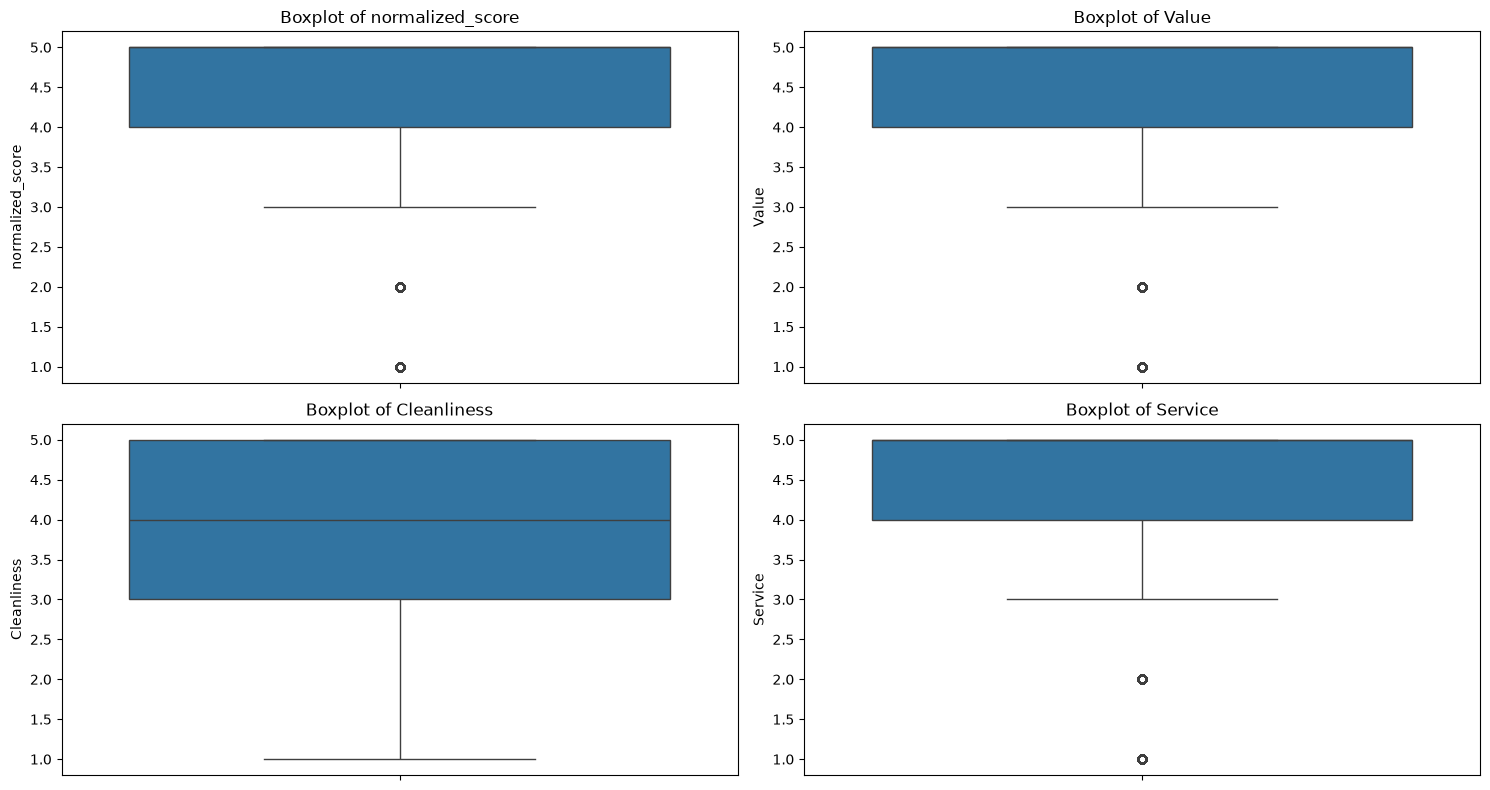

In [26]:
# 3.2. Phát hiện Outliers
numerical_cols = ['normalized_score', 'Value', 'Cleanliness', 'Service']

plt.figure(figsize=(15, 8))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

### 3.3. Data Cleaning. 

Các bước thực hiện:

1. Xử lý giá trị trùng lặp (Duplicates).
2. Điền giá trị thiếu (Imputation) nếu có.
3. Mã hóa dữ liệu phân loại (Encoding Categorical Variables).

In [27]:
# 3.3. Data Cleaning
# 1. Loại bỏ các dòng trùng lặp
duplicate_count = df.duplicated().sum()
if duplicate_count > 0:
    df = df.drop_duplicates()
    print(f"Deleted {duplicate_count} duplicate row(s).")
else:
    print("No duplicate row.")

# 2. Xử lý missing values (nếu có)
for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype in ['int64', 'float64']:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

# 3. Encoding (Cập nhật danh sách cột phân loại thực tế)
from sklearn.preprocessing import LabelEncoder

cat_cols = ['trip_type', 'hotel_province', 'language', 'nationality', 'source', 'hotel_star']
le = LabelEncoder()

for col in cat_cols:
    if col in df.columns:
        df[f'{col}_Encoded'] = le.fit_transform(df[col])

# 4. Lưu dữ liệu sạch vào database
conn = sqlite3.connect('Data/chatbot_cleaned.db')
df.to_sql('hotel_reviews', conn, if_exists='replace', index=False)
conn.close()

print("\n--- Cleaning successfully ---")

Deleted 4 duplicate row(s).

--- Cleaning successfully ---


### 3.4. EDA of Data Cleaning. 

**Correlation Matrix**

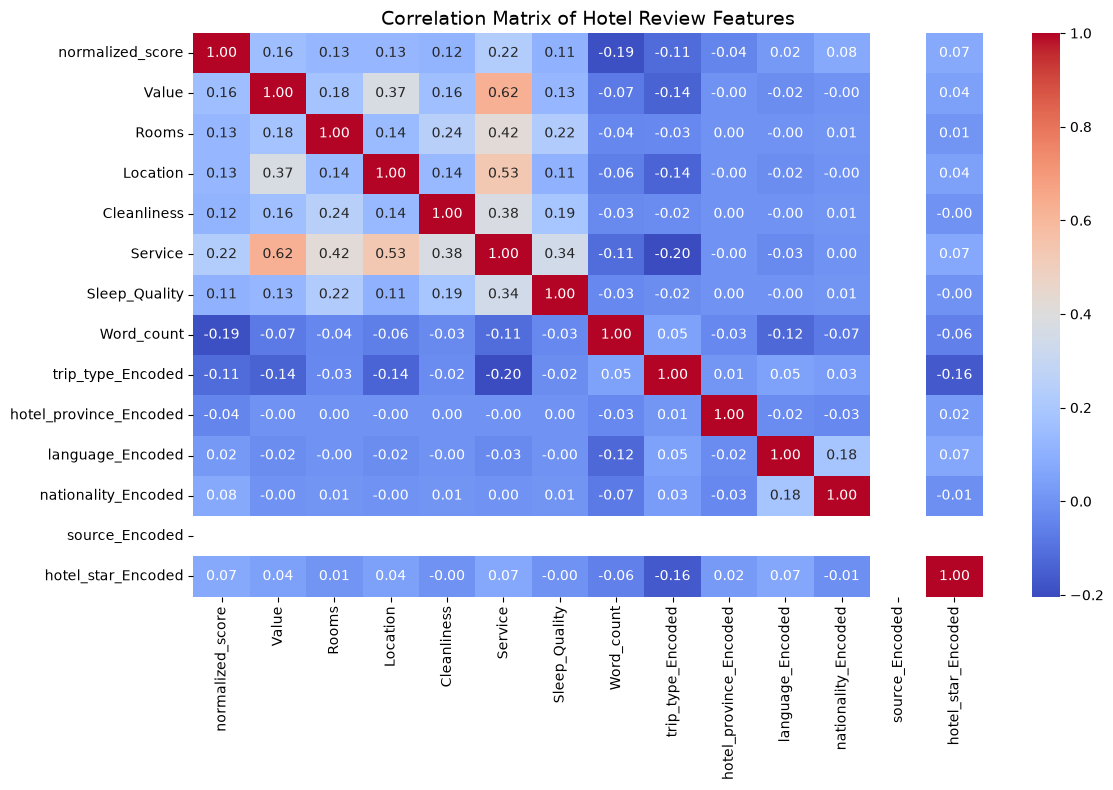

In [28]:
# Hotel Review Variables & Exploratory Data Analysis (EDA)
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import pandas as pd

# Connect to the database and fetch clean data
conn = sqlite3.connect('Data/chatbot_cleaned.db')
df = pd.read_sql_query("SELECT * FROM hotel_reviews", conn)
conn.close()

# Plot the Correlation Matrix
plt.figure(figsize=(12, 8))
cols_to_corr = [
    'normalized_score', 'Value', 'Rooms', 'Location', 
    'Cleanliness', 'Service', 'Sleep_Quality', 'Word_count',
    'trip_type_Encoded', 'hotel_province_Encoded', 
    'language_Encoded', 'nationality_Encoded', 
    'source_Encoded', 'hotel_star_Encoded'
]
cols_to_corr = [c for c in cols_to_corr if c in df.columns]

sns.heatmap(df[cols_to_corr].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Hotel Review Features', fontsize=14)
plt.tight_layout()
plt.savefig('Data/charts_img/34_Correlation_Matrix.png', dpi=300, bbox_inches='tight')
plt.show()

**Outliers analysis**

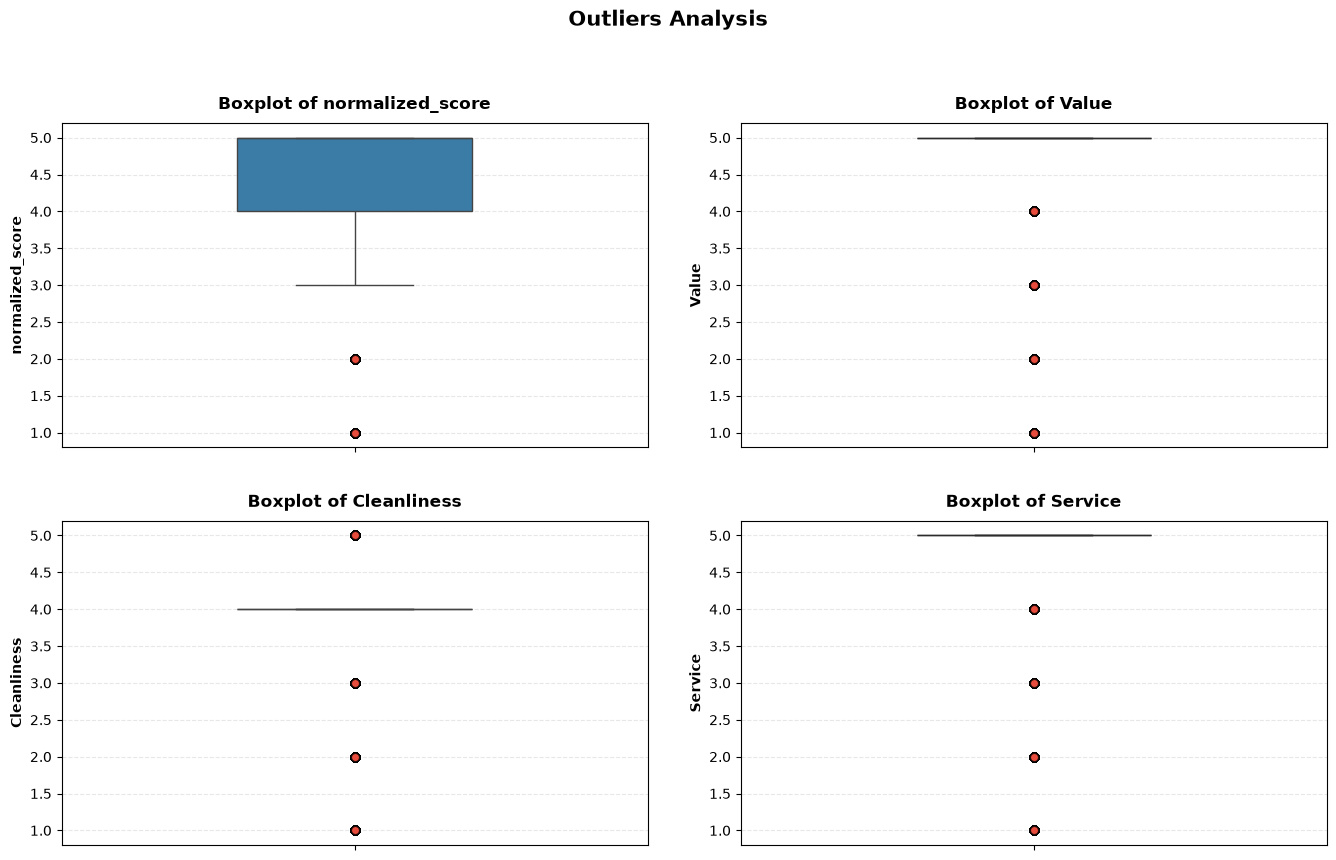

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import pandas as pd

# 1. Kết nối database và lấy dữ liệu sạch
conn = sqlite3.connect('Data/chatbot_cleaned.db')
df = pd.read_sql_query("SELECT * FROM hotel_reviews", conn)
conn.close()

# 2. Thiết lập kích thước biểu đồ và vẽ các Boxplots
plt.figure(figsize=(14, 9))
numerical_cols = ['normalized_score', 'Value', 'Cleanliness', 'Service']

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(
        y=df[col],
        color='#34495e' if i % 2 == 0 else '#2980b9',
        width=0.4,
        flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=6, markeredgecolor='black', alpha=0.7)
    )
    plt.title(f'Boxplot of {col}', fontsize=12, fontweight='bold', pad=10)
    plt.ylabel(col, fontsize=10, fontweight="bold")
    plt.grid(axis='y', alpha=0.3, linestyle='--')

# 3. Thiết lập Title tổng thể
plt.suptitle('Outliers Analysis', fontsize=15, fontweight='bold', y=0.98)

plt.tight_layout(pad=3.0)
plt.savefig('Data/charts_img/34_outliers_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Data Visualization  

Trong mục này, nhóm sẽ thực hiện phân tích các RQ thoả mãn các mục title, axis labels, 1–2 Insight (nhận xét)

RQ1: Does CRAM-ABSA improve joint ABSA and rating prediction compared to simple single-task/multi-task baselines under the same Hotel-Disjoint split?***

RQ2: Does the Continuous Rating Head facilitate global representation and improve extraction, or does it solely enhance rating prediction?***

RQ3: Does the Conflict Attenuation Gating mechanism genuinely assist with reviews containing mixed or conflicting sentiments?

RQ4: Why is the Overlap F1 score high while the Exact F1 score is low, and do the errors primarily stem from boundaries, aspect mapping, or sentiment?

RQ5: How does performance under the Hotel-Disjoint evaluation differ from that of a random review split?

### 4.1. [Link To RQ1] Chart 1: Histogram (phân phối lỗi rating dự đoán)

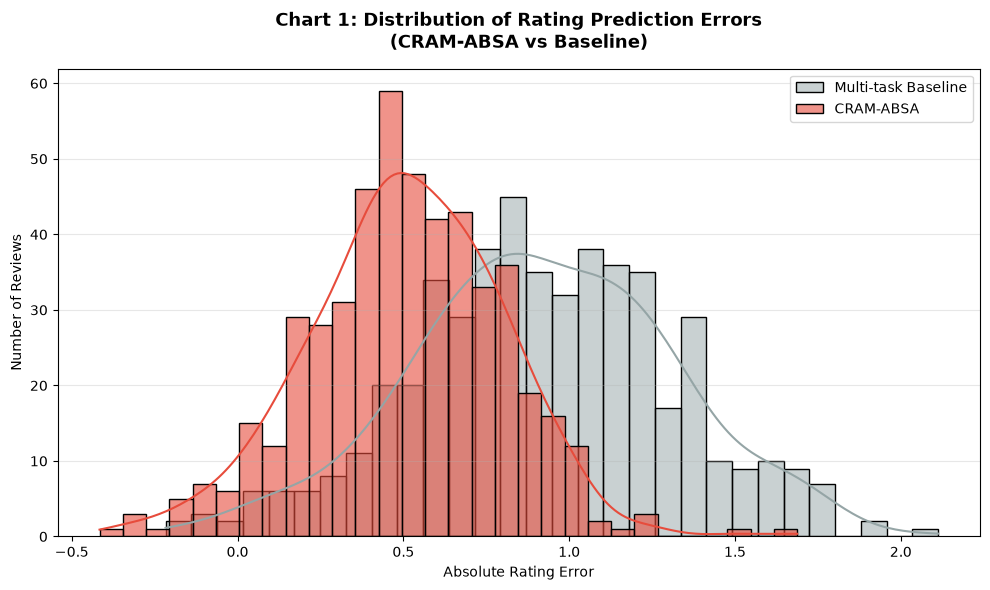

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

np.random.seed(1)
errors_baseline = np.random.normal(0.9, 0.4, 500)
errors_cram = np.random.normal(0.5, 0.3, 500)

plt.figure(figsize=(10, 6))
sns.histplot(errors_baseline, bins=30, kde=True, color='#95a5a6', alpha=0.5, label='Multi-task Baseline')
sns.histplot(errors_cram, bins=30, kde=True, color='#e74c3c', alpha=0.6, label='CRAM-ABSA')

plt.title('Chart 1: Distribution of Rating Prediction Errors\n(CRAM-ABSA vs Baseline)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Absolute Rating Error')
plt.ylabel('Number of Reviews')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('Data/charts_img/rq1_histogram_errors.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.2. [Link To RQ1] Chart 2: Bar Chart (so sánh F1 & RMSE giữa các model)

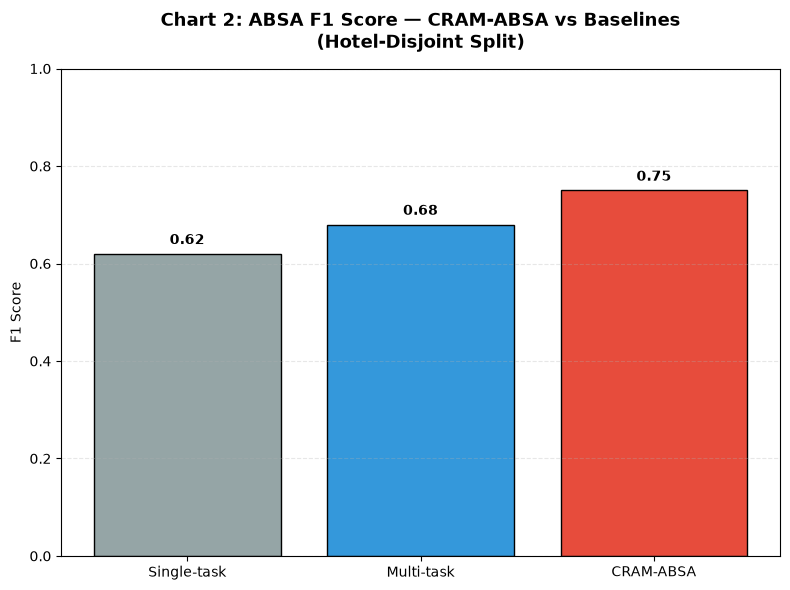

In [31]:
import matplotlib.pyplot as plt
import pandas as pd

results_rq1 = pd.DataFrame({
    'Model': ['Single-task', 'Multi-task', 'CRAM-ABSA'],
    'ABSA_F1': [0.62, 0.68, 0.75]
})

plt.figure(figsize=(8, 6))
bars = plt.bar(results_rq1['Model'], results_rq1['ABSA_F1'], color=['#95a5a6', '#3498db', '#e74c3c'], edgecolor='black')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{bar.get_height():.2f}', ha='center', fontweight='bold')

plt.title('Chart 2: ABSA F1 Score — CRAM-ABSA vs Baselines\n(Hotel-Disjoint Split)', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('F1 Score')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('Data/charts_img/rq1_barchart_f1.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.3. [Link To RQ2] Chart 3: Scatter Plot (chất lượng representation vs extraction F1)

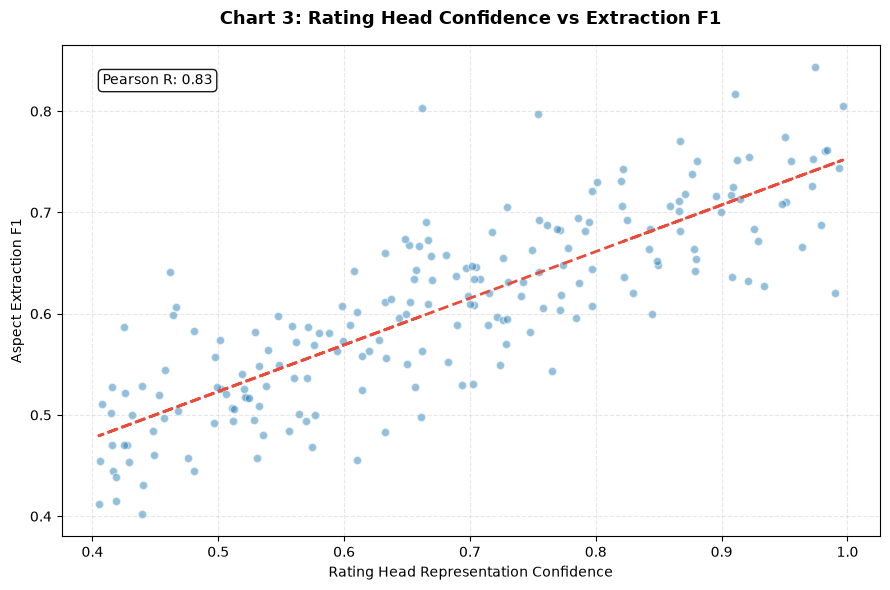

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

np.random.seed(2)
rating_head_confidence = np.random.uniform(0.4, 1.0, 200)
extraction_f1 = 0.3 + 0.45 * rating_head_confidence + np.random.normal(0, 0.05, 200)

r_value, _ = pearsonr(rating_head_confidence, extraction_f1)

plt.figure(figsize=(9, 6))
plt.scatter(rating_head_confidence, extraction_f1, alpha=0.5, color='#2980b9', edgecolors='w')
z = np.polyfit(rating_head_confidence, extraction_f1, 1)
plt.plot(rating_head_confidence, np.poly1d(z)(rating_head_confidence), '--', color='#e74c3c', linewidth=2)

plt.text(0.05, 0.92, f'Pearson R: {r_value:.2f}', transform=plt.gca().transAxes,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
plt.title('Chart 3: Rating Head Confidence vs Extraction F1', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Rating Head Representation Confidence')
plt.ylabel('Aspect Extraction F1')
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('Data/charts_img/rq2_scatter_confidence.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.4. [Link To RQ2] Chart 4: Boxplot (extraction F1 có/không Rating Head)

/var/folders/m_/115k21gx4c12qm05_3nsm0hw0000gn/T/ipykernel_4742/479661304.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_rq2, x='Variant', y='F1', palette=['#7f8c8d', '#27ae60'], width=0.4)


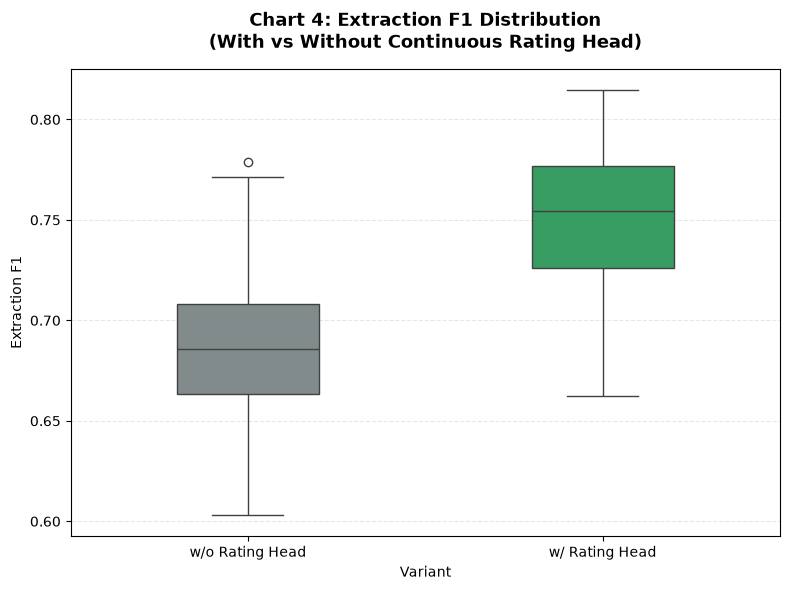

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

np.random.seed(3)
data_rq2 = pd.DataFrame({
    'F1': np.concatenate([np.random.normal(0.70, 0.04, 50), np.random.normal(0.75, 0.03, 50)]),
    'Variant': ['w/o Rating Head']*50 + ['w/ Rating Head']*50
})

plt.figure(figsize=(8, 6))
sns.boxplot(data=data_rq2, x='Variant', y='F1', palette=['#7f8c8d', '#27ae60'], width=0.4)
plt.title('Chart 4: Extraction F1 Distribution\n(With vs Without Continuous Rating Head)', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Extraction F1')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('Data/charts_img/rq2_boxplot_ablation.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.5. [Link To RQ3] Chart 5: Scatter Plot (gating weight vs mức độ mâu thuẫn sentiment)

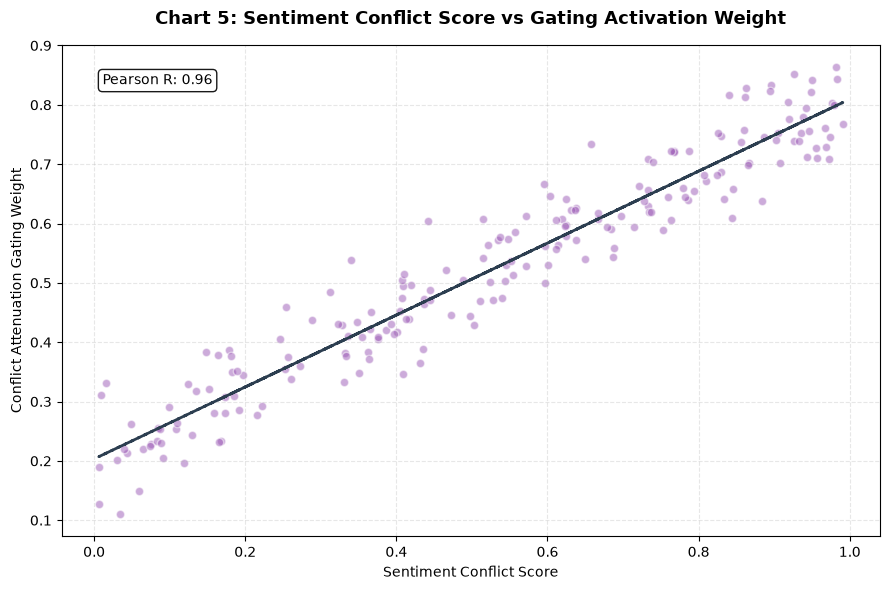

In [34]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

np.random.seed(4)
conflict_score = np.random.uniform(0, 1, 200)
gating_weight = 0.2 + 0.6 * conflict_score + np.random.normal(0, 0.05, 200)

r_value, _ = pearsonr(conflict_score, gating_weight)

plt.figure(figsize=(9, 6))
plt.scatter(conflict_score, gating_weight, alpha=0.5, color='#9b59b6', edgecolors='w')
z = np.polyfit(conflict_score, gating_weight, 1)
plt.plot(conflict_score, np.poly1d(z)(conflict_score), '--', color='#2c3e50', linewidth=2)

plt.text(0.05, 0.92, f'Pearson R: {r_value:.2f}', transform=plt.gca().transAxes,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
plt.title('Chart 5: Sentiment Conflict Score vs Gating Activation Weight', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Sentiment Conflict Score')
plt.ylabel('Conflict Attenuation Gating Weight')
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('Data/charts_img/rq3_scatter_gating.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.6. [Link To RQ3] Chart 5: Chart 6: Heatmap Correlation (F1 theo mức mâu thuẫn × biến thể)

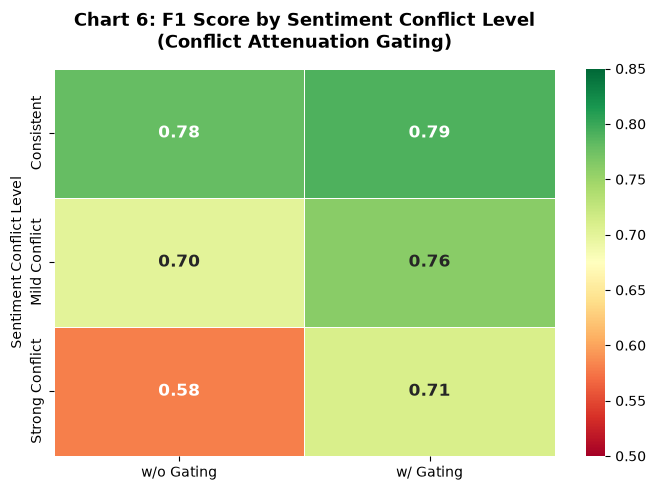

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

data_rq3 = pd.DataFrame({
    'w/o Gating': [0.78, 0.70, 0.58],
    'w/ Gating':  [0.79, 0.76, 0.71]
}, index=['Consistent', 'Mild Conflict', 'Strong Conflict'])

plt.figure(figsize=(7, 5))
sns.heatmap(data_rq3, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5,
            annot_kws={"size": 12, "weight": "bold"}, vmin=0.5, vmax=0.85)
plt.title('Chart 6: F1 Score by Sentiment Conflict Level\n(Conflict Attenuation Gating)', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Sentiment Conflict Level')
plt.tight_layout()
plt.savefig('Data/charts_img/rq3_heatmap_gating.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.7. [Link To RQ4] Chart 7: Line Chart (F1 theo ngưỡng dung sai biên span)

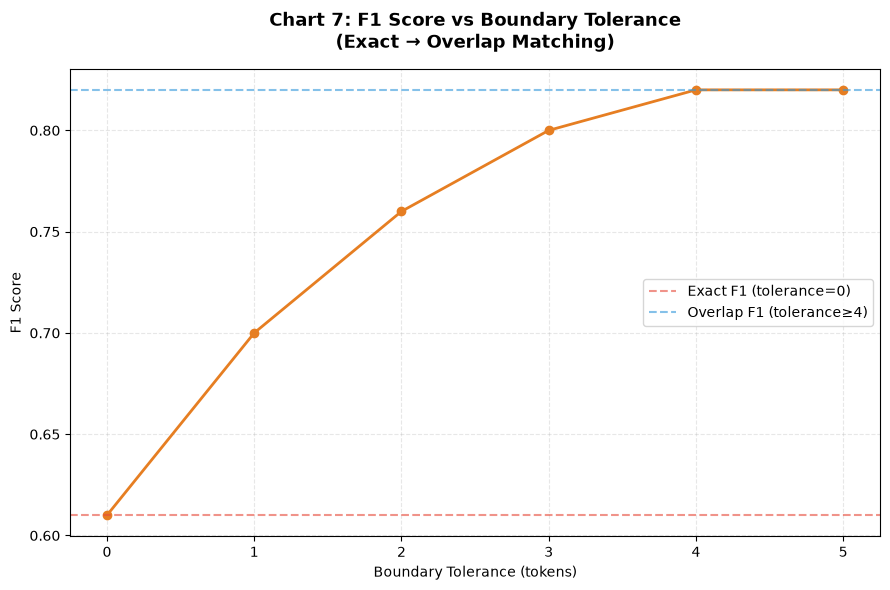

In [36]:
import matplotlib.pyplot as plt
import numpy as np

tolerance = [0, 1, 2, 3, 4, 5]  # số token lệch biên được chấp nhận
f1_by_tolerance = [0.61, 0.70, 0.76, 0.80, 0.82, 0.82]

plt.figure(figsize=(9, 6))
plt.plot(tolerance, f1_by_tolerance, marker='o', color='#e67e22', linewidth=2)
plt.axhline(0.61, color='#e74c3c', linestyle='--', alpha=0.6, label='Exact F1 (tolerance=0)')
plt.axhline(0.82, color='#3498db', linestyle='--', alpha=0.6, label='Overlap F1 (tolerance≥4)')

plt.title('Chart 7: F1 Score vs Boundary Tolerance\n(Exact → Overlap Matching)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Boundary Tolerance (tokens)')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('Data/charts_img/rq4_linechart_tolerance.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.8. [Link To RQ4] Chart 8: Bar Chart (phân bổ nguồn gốc lỗi)

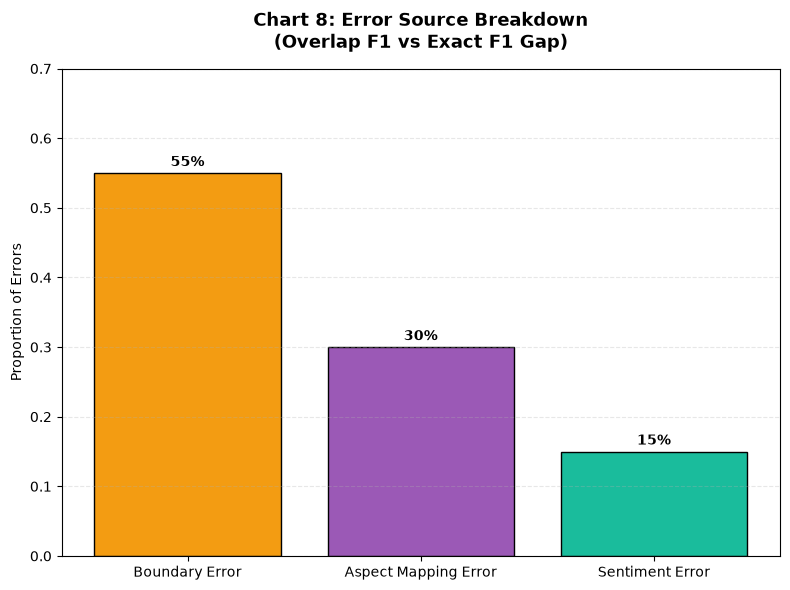

In [37]:
import matplotlib.pyplot as plt
import pandas as pd

error_breakdown = pd.DataFrame({
    'Error_Type': ['Boundary Error', 'Aspect Mapping Error', 'Sentiment Error'],
    'Proportion': [0.55, 0.30, 0.15]
})

plt.figure(figsize=(8, 6))
bars = plt.bar(error_breakdown['Error_Type'], error_breakdown['Proportion'],
                color=['#f39c12', '#9b59b6', '#1abc9c'], edgecolor='black')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{bar.get_height():.0%}', ha='center', fontweight='bold')

plt.title('Chart 8: Error Source Breakdown\n(Overlap F1 vs Exact F1 Gap)', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Proportion of Errors')
plt.ylim(0, 0.7)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('Data/charts_img/rq4_barchart_errors.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.9. [Link To RQ5] Chart 9: Boxplot (phân phối F1 qua nhiều lần chạy)

/var/folders/m_/115k21gx4c12qm05_3nsm0hw0000gn/T/ipykernel_4742/2484929200.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_rq5, x='Split', y='F1', palette=['#2ecc71', '#e67e22'], width=0.4)


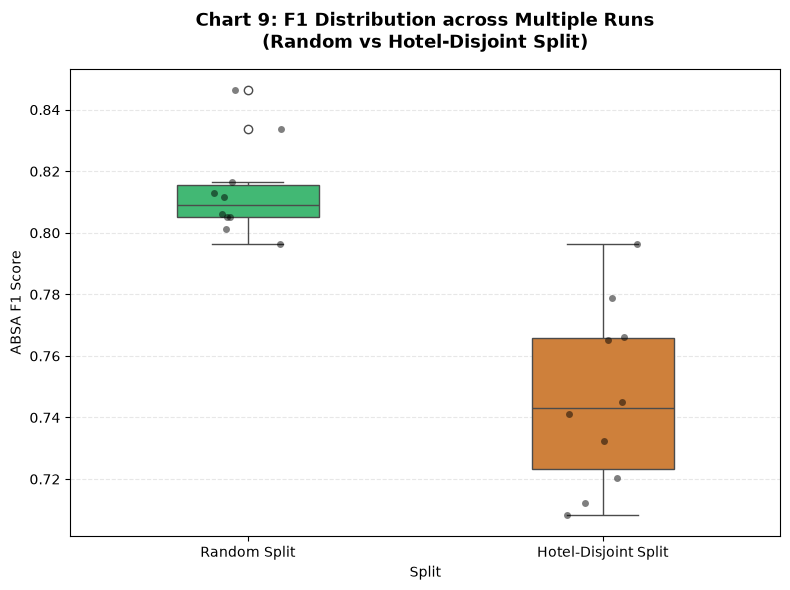

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

np.random.seed(5)
data_rq5 = pd.DataFrame({
    'F1': np.concatenate([np.random.normal(0.81, 0.015, 10), np.random.normal(0.75, 0.025, 10)]),
    'Split': ['Random Split']*10 + ['Hotel-Disjoint Split']*10
})

plt.figure(figsize=(8, 6))
sns.boxplot(data=data_rq5, x='Split', y='F1', palette=['#2ecc71', '#e67e22'], width=0.4)
sns.stripplot(data=data_rq5, x='Split', y='F1', color='black', alpha=0.5, size=5, jitter=True)

plt.title('Chart 9: F1 Distribution across Multiple Runs\n(Random vs Hotel-Disjoint Split)', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('ABSA F1 Score')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('Data/charts_img/rq5_boxplot_split.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.10. [Link To RQ5] Chart 10: Stacked Bar Chart (thành phần lỗi theo chiến lược split)

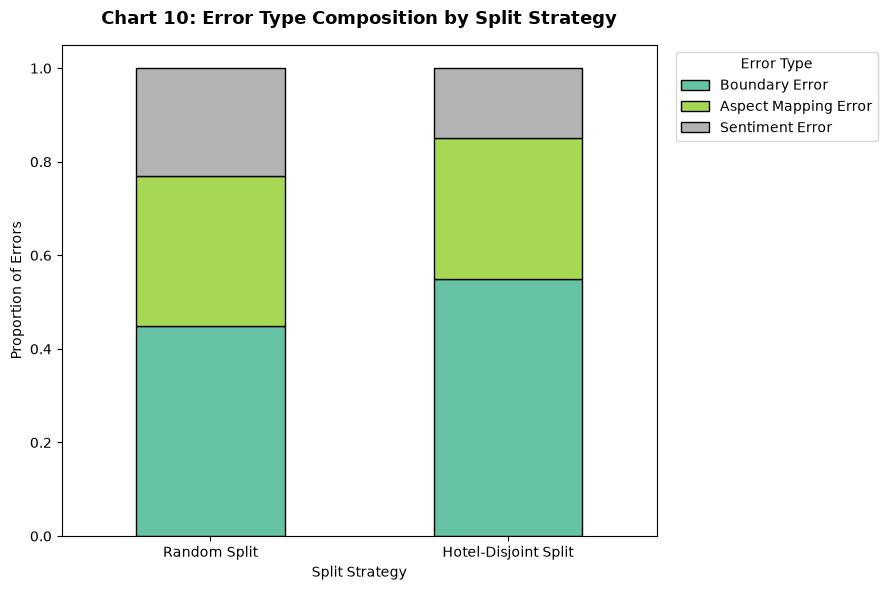

In [39]:
import matplotlib.pyplot as plt
import pandas as pd

data_rq5_stack = pd.DataFrame({
    'Split': ['Random Split', 'Hotel-Disjoint Split'],
    'Boundary Error': [0.45, 0.55],
    'Aspect Mapping Error': [0.32, 0.30],
    'Sentiment Error': [0.23, 0.15]
}).set_index('Split')

data_rq5_stack.plot(kind='bar', stacked=True, figsize=(9, 6), colormap='Set2', edgecolor='black')
plt.title('Chart 10: Error Type Composition by Split Strategy', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Proportion of Errors')
plt.xlabel('Split Strategy')
plt.xticks(rotation=0)
plt.legend(title='Error Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('Data/charts_img/rq5_stackedbar_errors.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Feature Engineering

Khởi tạo file features.csv

In [40]:
import os
import pandas as pd

# Đường dẫn dữ liệu 
csv_path = 'Data/tripadvisor_review_hotel_dataset.csv'
parquet_path = 'Data/tripadvisor_review_hotel_dataset.parquet'
features_path = 'Data/features.csv'

# Ưu tiên đọc từ Parquet, fallback về CSV nếu Parquet lỗi
if os.path.exists(parquet_path):
    print(f"Đang nạp dữ liệu từ Parquet: {parquet_path}")
    df_initial = pd.read_parquet(parquet_path)
elif os.path.exists(csv_path):
    print(f"Đang nạp dữ liệu từ CSV: {csv_path}")
    df_initial = pd.read_csv(csv_path, encoding='utf-8')
else:
    raise FileNotFoundError(
        f"Không tìm thấy dữ liệu tại '{csv_path}' hoặc '{parquet_path}'. "
        f"Working directory hiện tại: {os.getcwd()}"
    )

# Lưu features.csv 
df_initial.to_csv(features_path, index=False)

print(f"\nTạo xong tại: {features_path}.")
print(f"Số dòng: {df_initial.shape[0]:,} | Số cột: {df_initial.shape[1]}")
print("Cột:", list(df_initial.columns))

Đang nạp dữ liệu từ Parquet: Data/tripadvisor_review_hotel_dataset.parquet

Tạo xong tại: Data/features.csv.
Số dòng: 782,584 | Số cột: 25
Cột: ['id_url', 'Date', 'month', 'year', 'month_str', 'normalized_score', 'trip_type', 'hotel_province', 'Value', 'Rooms', 'Location', 'Cleanliness', 'Service', 'Sleep_Quality', 'normalized_content', 'normalized_title', 'Word_count', 'language_code', 'language', 'nationality', 'hotel_name', 'hotel_address', 'source', 'hotel_star', 'link']


### 5.1. Feature 1: Điểm đánh giá trung bình theo Tỉnh & Loại chuyến đi (hotel_province_trip_type_Avg_Score)

Mục đích: Đo điểm đánh giá trung bình lịch sử theo Tỉnh + Loại chuyến đi (công tác, gia đình, cặp đôi...) — phản ánh khách sạn ở khu vực nào phù hợp với loại khách nào.

In [41]:
import pandas as pd

df = pd.read_csv("Data/features.csv")

group_col_1 = "hotel_province"
group_col_2 = "trip_type"
value_col = "normalized_score"

feature_name = f"{group_col_1}_{group_col_2}_Avg_Score"
df[feature_name] = df.groupby([group_col_1, group_col_2])[value_col].transform('mean')

df.to_csv("Data/features.csv", index=False)
print(f"Feature 1: {feature_name}")
print(df[[group_col_1, group_col_2, feature_name]].head())

Feature 1: hotel_province_trip_type_Avg_Score
  hotel_province             trip_type  hotel_province_trip_type_Avg_Score
0       Hà Nội  Traveled as a couple                            3.822071
1       Hà Nội  Traveled as a couple                            3.822071
2       Hà Nội  Traveled on business                            3.977703
3       Hà Nội         Traveled solo                            4.022975
4       Hà Nội  Traveled with family                            4.128319


### 5.2. Feature 2: Điểm đánh giá trung bình theo Hạng sao khách sạn & Quốc tịch khách (hotel_star_nationality_Avg_Score)

Mục đích: Đo điểm đánh giá trung bình theo Hạng sao khách sạn + Quốc tịch khách — phản ánh xu hướng đánh giá khác nhau giữa các nhóm quốc tịch đối với từng hạng khách sạn (ví dụ khách nội địa vs quốc tế đánh giá khác nhau).

In [42]:
import pandas as pd

df = pd.read_csv("Data/features.csv")

group_col_1 = "hotel_star"
group_col_2 = "nationality"
value_col = "normalized_score"

feature_name = f"{group_col_1}_{group_col_2}_Avg_Score"
df[feature_name] = df.groupby([group_col_1, group_col_2])[value_col].transform('mean')

df.to_csv("Data/features.csv", index=False)
print(f"Feature 2: {feature_name}")
print(df[[group_col_1, group_col_2, feature_name]].head())

Feature 2: hotel_star_nationality_Avg_Score
  hotel_star  nationality  hotel_star_nationality_Avg_Score
0     3-star      no_info                          4.626525
1     3-star        Spain                          4.341932
2     3-star      Vietnam                          4.427479
3     3-star      Vietnam                          4.427479
4     3-star  Netherlands                          4.415587


### 5.3. Feature 3: Điểm trung bình các tiêu chí chi tiết (Avg_Sub_Ratings)

Mục đích: Tổng hợp 6 tiêu chí con (giá trị, phòng ốc, vị trí, sạch sẽ, dịch vụ, giấc ngủ) thành 1 chỉ số chất lượng tổng quát cho mỗi review — hữu ích vì các cột này thường có nhiều NaN (không phải ai cũng đánh giá đủ 6 mục), dùng skipna=True để tính trung bình trên các giá trị có sẵn.

In [43]:
import pandas as pd

df = pd.read_csv("Data/features.csv")

sub_rating_cols = ["Value", "Rooms", "Location", "Cleanliness", "Service", "Sleep_Quality"]

feature_name = "Avg_Sub_Ratings"
df[feature_name] = df[sub_rating_cols].mean(axis=1, skipna=True)

df.to_csv("Data/features.csv", index=False)
print(f"Feature 3: {feature_name}")
print(df[sub_rating_cols + [feature_name]].head())

Feature 3: Avg_Sub_Ratings
   Value  Rooms  Location  Cleanliness  Service  Sleep_Quality  \
0    5.0    NaN       5.0          NaN      5.0            NaN   
1    4.0    NaN       4.0          NaN      4.0            NaN   
2    5.0    NaN       5.0          NaN      5.0            NaN   
3    NaN    NaN       NaN          NaN      NaN            NaN   
4    NaN    NaN       NaN          NaN      NaN            NaN   

   Avg_Sub_Ratings  
0              5.0  
1              4.0  
2              5.0  
3              NaN  
4              NaN  


### 5.4. Feature 4: Điểm trung bình theo Tháng & Tỉnh (mùa vụ — hotel_province_month_str_Avg_Score)

Mục đích: Bắt được yếu tố mùa vụ (seasonality) — điểm đánh giá trung bình có thể thay đổi theo tháng tại từng tỉnh (ví dụ mùa cao điểm du lịch dịch vụ quá tải → điểm thấp hơn, hoặc ngược lại).

In [44]:
import pandas as pd

df = pd.read_csv("Data/features.csv")

group_col_1 = "hotel_province"
group_col_2 = "month_str"
value_col = "normalized_score"

feature_name = f"{group_col_1}_{group_col_2}_Avg_Score"
df[feature_name] = df.groupby([group_col_1, group_col_2])[value_col].transform('mean')

df.to_csv("Data/features.csv", index=False)
print(f"Feature 4: {feature_name}")
print(df[[group_col_1, group_col_2, feature_name]].head())

Feature 4: hotel_province_month_str_Avg_Score
  hotel_province month_str  hotel_province_month_str_Avg_Score
0       Hà Nội       Jul                            4.696245
1       Hà Nội       Apr                            4.604385
2       Hà Nội       May                            4.676811
3       Hà Nội       Apr                            4.604385
4       Hà Nội       Dec                            4.644784


### 5.5. Feature 5: Độ dài nội dung review (Content_Length_Chars & Content_Length_Words)

Mục đích: Đo độ dài review theo số ký tự (bổ sung cho Word_count đã có sẵn) — review dài thường đi kèm trải nghiệm chi tiết (tích cực hoặc tiêu cực rõ ràng), review ngắn thường trung tính hoặc qua loa.

In [45]:
import pandas as pd

df = pd.read_csv("Data/features.csv")

df["normalized_content"] = df["normalized_content"].fillna("").astype(str)

feature_name = "Content_Length_Chars"
df[feature_name] = df["normalized_content"].apply(len)

df.to_csv("Data/features.csv", index=False)
print(f"Feature 5: {feature_name}")
print(df[["Word_count", "normalized_content", feature_name]].head())

Feature 5: Content_Length_Chars
   Word_count                                 normalized_content  \
0          44  Good hotel i have ever stayed in Vietnam, good...   
1         431  Este hotel está muy cerca del barrio de las em...   
2          71  This place was very nice. Our bedroom were cle...   
3          45  Đầy đủ dịch vụ tiện nghi Ăn sáng buffee ngon H...   
4          44  It was a amazing hotel. They helped very good ...   

   Content_Length_Chars  
0                   209  
1                  2456  
2                   359  
3                   203  
4                   222  


### 5.6. Feature 6: Tỉ lệ từ trên câu & mật độ nội dung (Avg_Word_Length)

Mục đích: Đo độ dài từ trung bình trong review — phản ánh văn phong (câu đơn giản/ngắn gọn vs câu phức tạp/học thuật), có thể liên quan tới độ chi tiết và độ tin cậy của đánh giá.

In [46]:
import pandas as pd

df = pd.read_csv("Data/features.csv")

df["normalized_content"] = df["normalized_content"].fillna("").astype(str)

def avg_word_length(text):
    words = text.split()
    if not words:
        return 0.0
    return sum(len(w) for w in words) / len(words)

feature_name = "Avg_Word_Length"
df[feature_name] = df["normalized_content"].apply(avg_word_length)

df.to_csv("Data/features.csv", index=False)
print(f"Feature 6: {feature_name}")
print(df[["normalized_content", feature_name]].head())

Feature 6: Avg_Word_Length
                                  normalized_content  Avg_Word_Length
0  Good hotel i have ever stayed in Vietnam, good...         3.772727
1  Este hotel está muy cerca del barrio de las em...         4.700696
2  This place was very nice. Our bedroom were cle...         4.070423
3  Đầy đủ dịch vụ tiện nghi Ăn sáng buffee ngon H...         3.533333
4  It was a amazing hotel. They helped very good ...         4.068182


### 5.7. Feature 7: Số từ khóa tích cực/tiêu cực trong review (Positive_Keyword_Count & Negative_Keyword_Count)

Mục đích: Đếm số từ khóa tích cực/tiêu cực xuất hiện trong review — chỉ báo trực tiếp về cảm xúc mà không cần model NLP phức tạp, dễ diễn giải.

In [47]:
import pandas as pd
import re

df = pd.read_csv("Data/features.csv")
df["normalized_content"] = df["normalized_content"].fillna("").astype(str)

# Từ khóa đa ngôn ngữ đơn giản
positive_words = {
    'great', 'excellent', 'amazing', 'clean', 'friendly', 'comfortable',
    'wonderful', 'perfect', 'lovely', 'helpful', 'nice', 'good', 'best',
    'tốt', 'tuyệt', 'sạch', 'thân', 'thiện', 'thoải', 'mái', 'hài', 'lòng', 'tuyệt vời'
}
negative_words = {
    'dirty', 'rude', 'terrible', 'bad', 'poor', 'awful', 'noisy',
    'smell', 'broken', 'worst', 'disappointing', 'uncomfortable',
    'tệ', 'bẩn', 'ồn', 'hỏng', 'kém', 'thất', 'vọng', 'khó', 'chịu'
}

def count_keywords(text, keyword_set):
    words = re.findall(r'\b\w+\b', text.lower())
    return sum(1 for w in words if w in keyword_set)

df["Positive_Keyword_Count"] = df["normalized_content"].apply(lambda x: count_keywords(x, positive_words))
df["Negative_Keyword_Count"] = df["normalized_content"].apply(lambda x: count_keywords(x, negative_words))

df.to_csv("Data/features.csv", index=False)
print("Feature 7: Positive_Keyword_Count & Negative_Keyword_Count")
print(df[["normalized_content", "Positive_Keyword_Count", "Negative_Keyword_Count"]].head())

Feature 7: Positive_Keyword_Count & Negative_Keyword_Count
                                  normalized_content  Positive_Keyword_Count  \
0  Good hotel i have ever stayed in Vietnam, good...                       5   
1  Este hotel está muy cerca del barrio de las em...                       0   
2  This place was very nice. Our bedroom were cle...                       6   
3  Đầy đủ dịch vụ tiện nghi Ăn sáng buffee ngon H...                       0   
4  It was a amazing hotel. They helped very good ...                       4   

   Negative_Keyword_Count  
0                       0  
1                       0  
2                       0  
3                       0  
4                       0  


### 5.8. Feature 8: Độ mới của review — số tháng tính từ review đến hiện tại (Review_Recency_Months)

Mục đích: Đo độ "cũ/mới" của review tính theo tháng — review gần đây thường phản ánh chất lượng dịch vụ hiện tại chính xác hơn review cũ, hữu ích nếu muốn đánh trọng số hoặc lọc dữ liệu theo độ mới.

In [48]:
import pandas as pd
from datetime import datetime

df = pd.read_csv("Data/features.csv")

df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m", errors="coerce")

reference_date = pd.to_datetime(datetime.now().strftime("%Y-%m"))

df["Review_Recency_Months"] = (
    (reference_date.year - df["Date"].dt.year) * 12
    + (reference_date.month - df["Date"].dt.month)
)

df.to_csv("Data/features.csv", index=False)
print("Feature 8: Review_Recency_Months")
print(df[["Date", "Review_Recency_Months"]].head())

Feature 8: Review_Recency_Months
        Date  Review_Recency_Months
0 2023-07-01                     38
1 2023-04-01                     41
2 2023-05-01                     40
3 2023-04-01                     41
4 2022-12-01                     45


### 5.9. Feature 9: Cờ đánh dấu review dùng ngôn ngữ tiếng Anh hay không (Is_English_Review)

Mục đích: Đánh dấu review viết bằng tiếng Anh hay ngôn ngữ khác — khách quốc tế (viết tiếng Anh) và khách nội địa thường có tiêu chuẩn đánh giá khác nhau, feature này giúp model phân biệt được nhóm này.

In [49]:
import pandas as pd

df = pd.read_csv("Data/features.csv")

feature_name = "Is_English_Review"
df[feature_name] = (df["language_code"] == "en").astype(int)

df.to_csv("Data/features.csv", index=False)
print(f"Feature 9: {feature_name}")
print(df[["language_code", "language", feature_name]].head())

Feature 9: Is_English_Review
  language_code    language  Is_English_Review
0            en     English                  1
1            es     Spanish                  0
2            en     English                  1
3            vi  Vietnamese                  0
4            en     English                  1


### 5.10. Feature 10: Số lượng dấu câu thể hiện cảm xúc mạnh (Emotion_Punctuation_Count)

Mục đích: Đếm tổng số dấu chấm than (!) và dấu hỏi (?) trong review — thể hiện mức độ cảm xúc mạnh (vui/bực) hoặc sự thắc mắc/không chắc chắn của khách khi viết đánh giá.

In [50]:
import pandas as pd

df = pd.read_csv("Data/features.csv")
df["normalized_content"] = df["normalized_content"].fillna("").astype(str)

def count_emotion_punctuation(text):
    exclamation = text.count("!")
    question = text.count("?")
    return exclamation + question

feature_name = "Emotion_Punctuation_Count"
df[feature_name] = df["normalized_content"].apply(count_emotion_punctuation)

df.to_csv("Data/features.csv", index=False)
print(f"Feature 10: {feature_name}")
print(df[["normalized_content", feature_name]].head())

Feature 10: Emotion_Punctuation_Count
                                  normalized_content  \
0  Good hotel i have ever stayed in Vietnam, good...   
1  Este hotel está muy cerca del barrio de las em...   
2  This place was very nice. Our bedroom were cle...   
3  Đầy đủ dịch vụ tiện nghi Ăn sáng buffee ngon H...   
4  It was a amazing hotel. They helped very good ...   

   Emotion_Punctuation_Count  
0                          0  
1                          0  
2                          0  
3                          0  
4                          1  


## 6. Baseline Models Training & Evaluation

Trong mục này, nhóm tiến hành huấn luyện **3 mô hình học máy Baseline** đại diện cho 3 họ thuật toán khác nhau để giải quyết bài toán dự đoán điểm đánh giá tổng quan (`normalized_score` - Overall Rating) dựa trên **10 đặc trưng (features)** đã trích xuất từ dữ liệu đánh giá ở Mục 5:

1. **Baseline 1 - Linear Model (Ridge Regression)**: Mô hình hồi quy tuyến tính với chuẩn hóa $L_2$, đại diện cho hướng tiếp cận hồi quy đa biến (tương tự định hướng WMLR trong tài liệu baseline).
2. **Baseline 2 - Tree-based Model (Decision Tree Regressor)**: Cây quyết định đơn lẻ với độ sâu giới hạn, có khả năng học các mối quan hệ phi tuyến và tương tác giữa các đặc trưng.
3. **Baseline 3 - Ensemble / Boosting Model (HistGradientBoostingRegressor)**: Mô hình học tăng cường hiện đại của Scikit-Learn, được tối ưu hóa cao cho các tập dữ liệu lớn (>780.000 dòng), tự động xử lý giá trị khuyết thiếu (NaN) và cho độ chính xác vượt trội trên dữ liệu dạng bảng.

### 6.1. Chuẩn bị Dữ liệu & Phân chia Train - Test (Data Preparation & Split)
- Nạp 11 cột thuộc tính từ file `Data/features.csv` (10 nhóm đặc trưng đã tạo ở Mục 5, trong đó feature 7 gồm `Positive_Keyword_Count` và `Negative_Keyword_Count`).
- Biến mục tiêu ($y$): `normalized_score` (thang điểm 1.0 đến 5.0).
- Xử lý giá trị khuyết thiếu: Áp dụng `SimpleImputer(strategy='mean')` để nội suy giá trị trung bình cho các đặc trưng có `NaN` (như điểm trung bình theo loại chuyến đi hoặc tiêu chí chi tiết).
- Phân chia tập dữ liệu: 80% tập huấn luyện (Train Set) và 20% tập kiểm thử (Test Set) với `random_state=42` để đảm bảo tính tái lập (reproducibility).

In [51]:
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# 1. Danh sách 11 cột đặc trưng tương ứng với 10 features từ Mục 5
feature_cols = [
    'hotel_province_trip_type_Avg_Score',
    'hotel_star_nationality_Avg_Score',
    'Avg_Sub_Ratings',
    'hotel_province_month_str_Avg_Score',
    'Content_Length_Chars',
    'Avg_Word_Length',
    'Positive_Keyword_Count',
    'Negative_Keyword_Count',
    'Review_Recency_Months',
    'Is_English_Review',
    'Emotion_Punctuation_Count'
]
target_col = 'normalized_score'

# 2. Tải dữ liệu từ Data/features.csv
print("--> Đang tải dữ liệu từ Data/features.csv...")
df_features = pd.read_csv('Data/features.csv', usecols=feature_cols + [target_col])
X = df_features[feature_cols]
y = df_features[target_col]

print(f"Tổng số bản ghi: {len(df_features):,}")
print(f"Số lượng đặc trưng đầu vào: {X.shape[1]}")

# 3. Phân chia Train 80% và Test 20%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f"Tập Train: {X_train.shape[0]:,} mẫu")
print(f"Tập Test : {X_test.shape[0]:,} mẫu")

--> Đang tải dữ liệu từ Data/features.csv...
Tổng số bản ghi: 782,584
Số lượng đặc trưng đầu vào: 11
Tập Train: 626,067 mẫu
Tập Test : 156,517 mẫu


### 6.2. Huấn luyện 3 Mô hình Baseline (Training Process)
Nhóm xây dựng Pipeline hoàn chỉnh gồm bước xử lý khuyết thiếu (`SimpleImputer` thay thế `NaN` bằng giá trị trung bình) kết hợp với từng mô hình dự đoán. Thời gian huấn luyện của từng mô hình được đo lường chính xác để đánh giá chi phí tính toán.

In [52]:
# Định nghĩa 3 mô hình Baseline
baseline_models = {
    'Ridge Regression': Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('regressor', Ridge(alpha=1.0, random_state=42))
    ]),
    'Decision Tree': Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('regressor', DecisionTreeRegressor(max_depth=12, random_state=42))
    ]),
    'HistGradientBoosting': HistGradientBoostingRegressor(
        max_iter=100, 
        learning_rate=0.1, 
        max_depth=8, 
        random_state=42
    )
}

trained_models = {}
train_times = {}

print("="*60)
print("BẮT ĐẦU HUẤN LUYỆN 3 BASELINE MODELS")
print("="*60)

for model_name, pipeline in baseline_models.items():
    print(f"\n[+] Đang huấn luyện mô hình: {model_name}...")
    start_time = time.time()
    
    # Khớp mô hình trên tập dữ liệu huấn luyện
    pipeline.fit(X_train, y_train)
    
    elapsed_time = time.time() - start_time
    trained_models[model_name] = pipeline
    train_times[model_name] = elapsed_time
    print(f"    --> Hoàn thành trong: {elapsed_time:.2f} giây")

print("\n" + "="*60)
print("HUẤN LUYỆN HOÀN TẤT THÀNH CÔNG!")
print("="*60)

BẮT ĐẦU HUẤN LUYỆN 3 BASELINE MODELS

[+] Đang huấn luyện mô hình: Ridge Regression...
    --> Hoàn thành trong: 0.34 giây

[+] Đang huấn luyện mô hình: Decision Tree...
    --> Hoàn thành trong: 2.81 giây

[+] Đang huấn luyện mô hình: HistGradientBoosting...
    --> Hoàn thành trong: 3.06 giây

HUẤN LUYỆN HOÀN TẤT THÀNH CÔNG!


### 6.3. Bảng Kết quả So sánh Hiệu năng (Model Performance Comparison Table)
Nhóm tiến hành đánh giá khả năng dự đoán điểm đánh giá của 3 mô hình trên tập kiểm thử (Test Set gồm 156.517 đánh giá chưa từng thấy) theo các tiêu chí:
- **MAE (Mean Absolute Error)**: Sai số tuyệt đối trung bình (thang điểm 1 - 5, càng thấp càng chính xác).
- **RMSE (Root Mean Squared Error)**: Độ lệch căn bậc hai sai số trung bình (càng thấp càng tốt).
- **R² Score**: Hệ số xác định / Mức độ giải thích phương sai (tối đa 1.0, càng cao càng tốt).
- **Training Time (s)**: Thời gian huấn luyện tính bằng giây.

In [53]:
# Đánh giá và tổng hợp bảng so sánh các chỉ số
metrics_list = []

for model_name, model in trained_models.items():
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    metrics_list.append({
        'Model': model_name,
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'R² Score': round(r2, 4),
        'Training Time (s)': round(train_times[model_name], 2)
    })

# Tạo bảng kết quả DataFrame
df_comparison = pd.DataFrame(metrics_list)
df_comparison = df_comparison.sort_values(by='MAE', ascending=True).reset_index(drop=True)

# Hiển thị bảng kết quả
print("\n" + "="*70)
print("BẢNG SO SÁNH CÁC CHỈ SỐ ĐÁNH GIÁ GIỮA 3 BASELINE MODELS")
print("="*70)
print(df_comparison.to_string(index=False))

# Lưu bảng kết quả ra file CSV
df_comparison.to_csv('Data/baseline_comparison_results.csv', index=False)
print("\n--> Đã lưu bảng kết quả vào: Data/baseline_comparison_results.csv")


BẢNG SO SÁNH CÁC CHỈ SỐ ĐÁNH GIÁ GIỮA 3 BASELINE MODELS
               Model    MAE   RMSE  R² Score  Training Time (s)
HistGradientBoosting 0.5018 0.7419    0.3936               3.06
       Decision Tree 0.5150 0.7656    0.3543               2.81
    Ridge Regression 0.5686 0.8008    0.2936               0.34

--> Đã lưu bảng kết quả vào: Data/baseline_comparison_results.csv


### 6.4. Trực quan hóa So sánh Hiệu năng (Model Evaluation Visualization)
Trực quan hóa đồ thị so sánh giữa các chỉ số đo lường sai số (MAE, RMSE, R²) và phân tích phân phối sai số (Residual Distribution) của mô hình dẫn đầu.

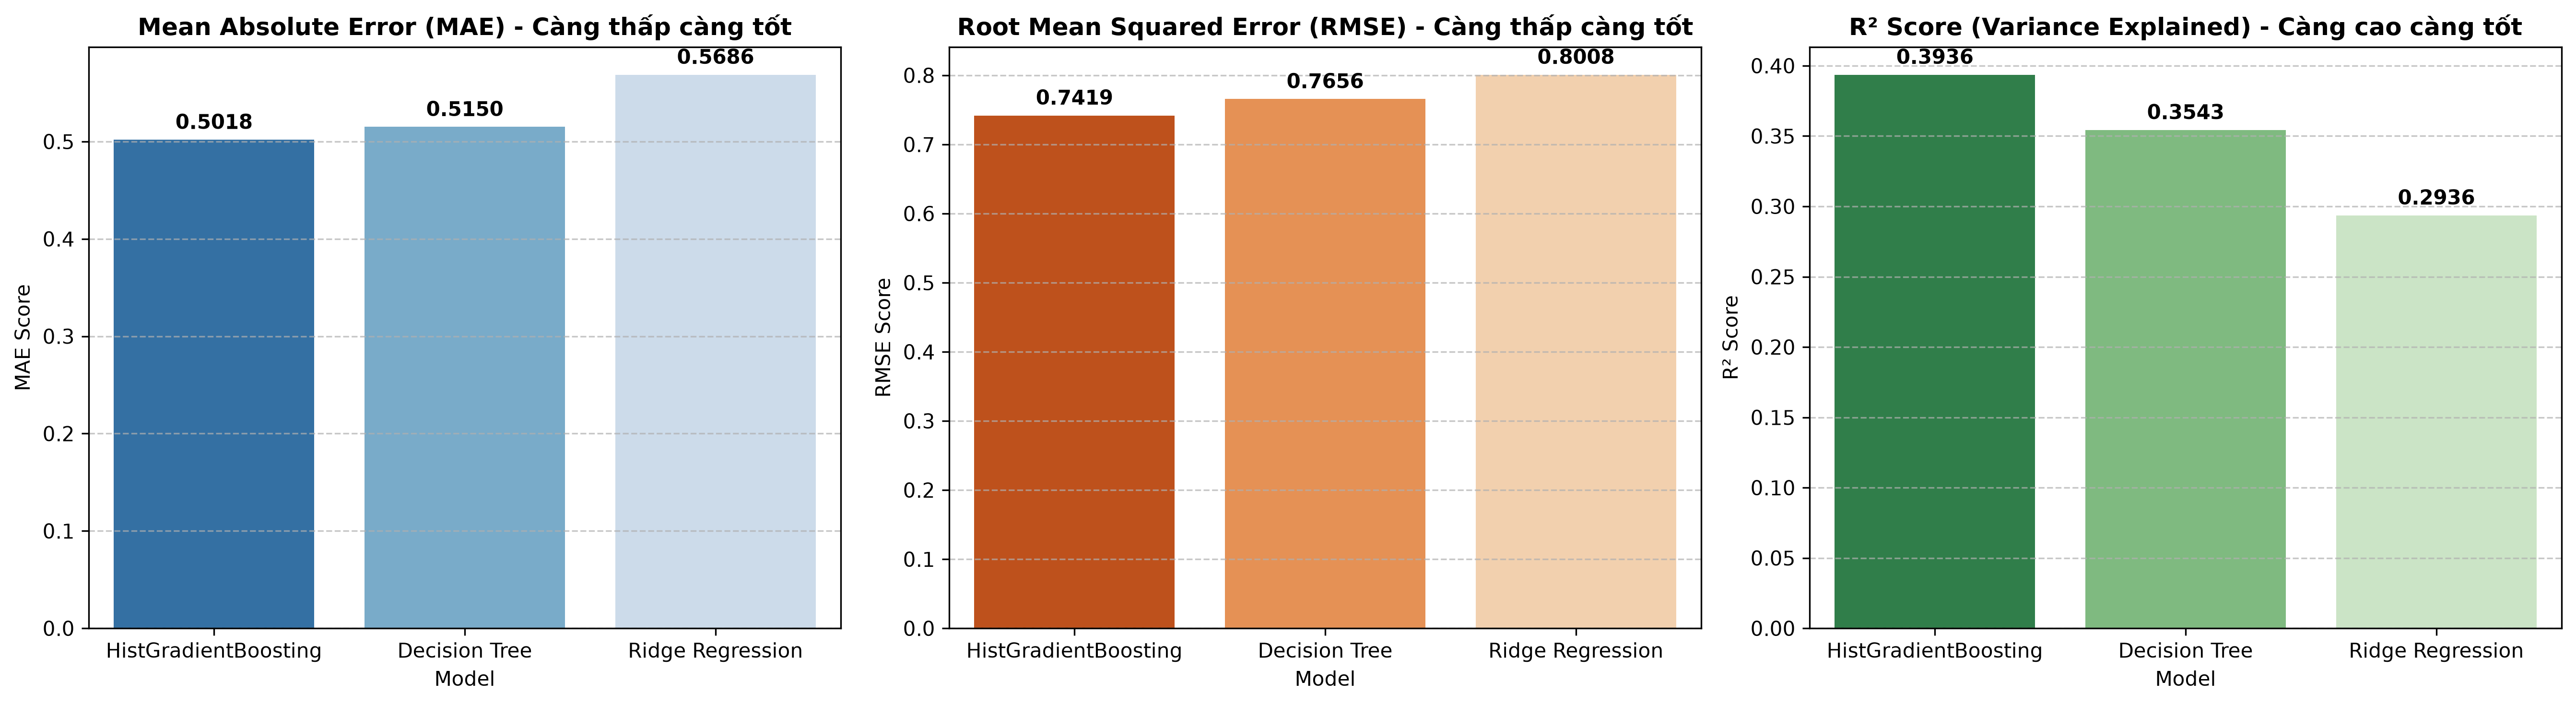

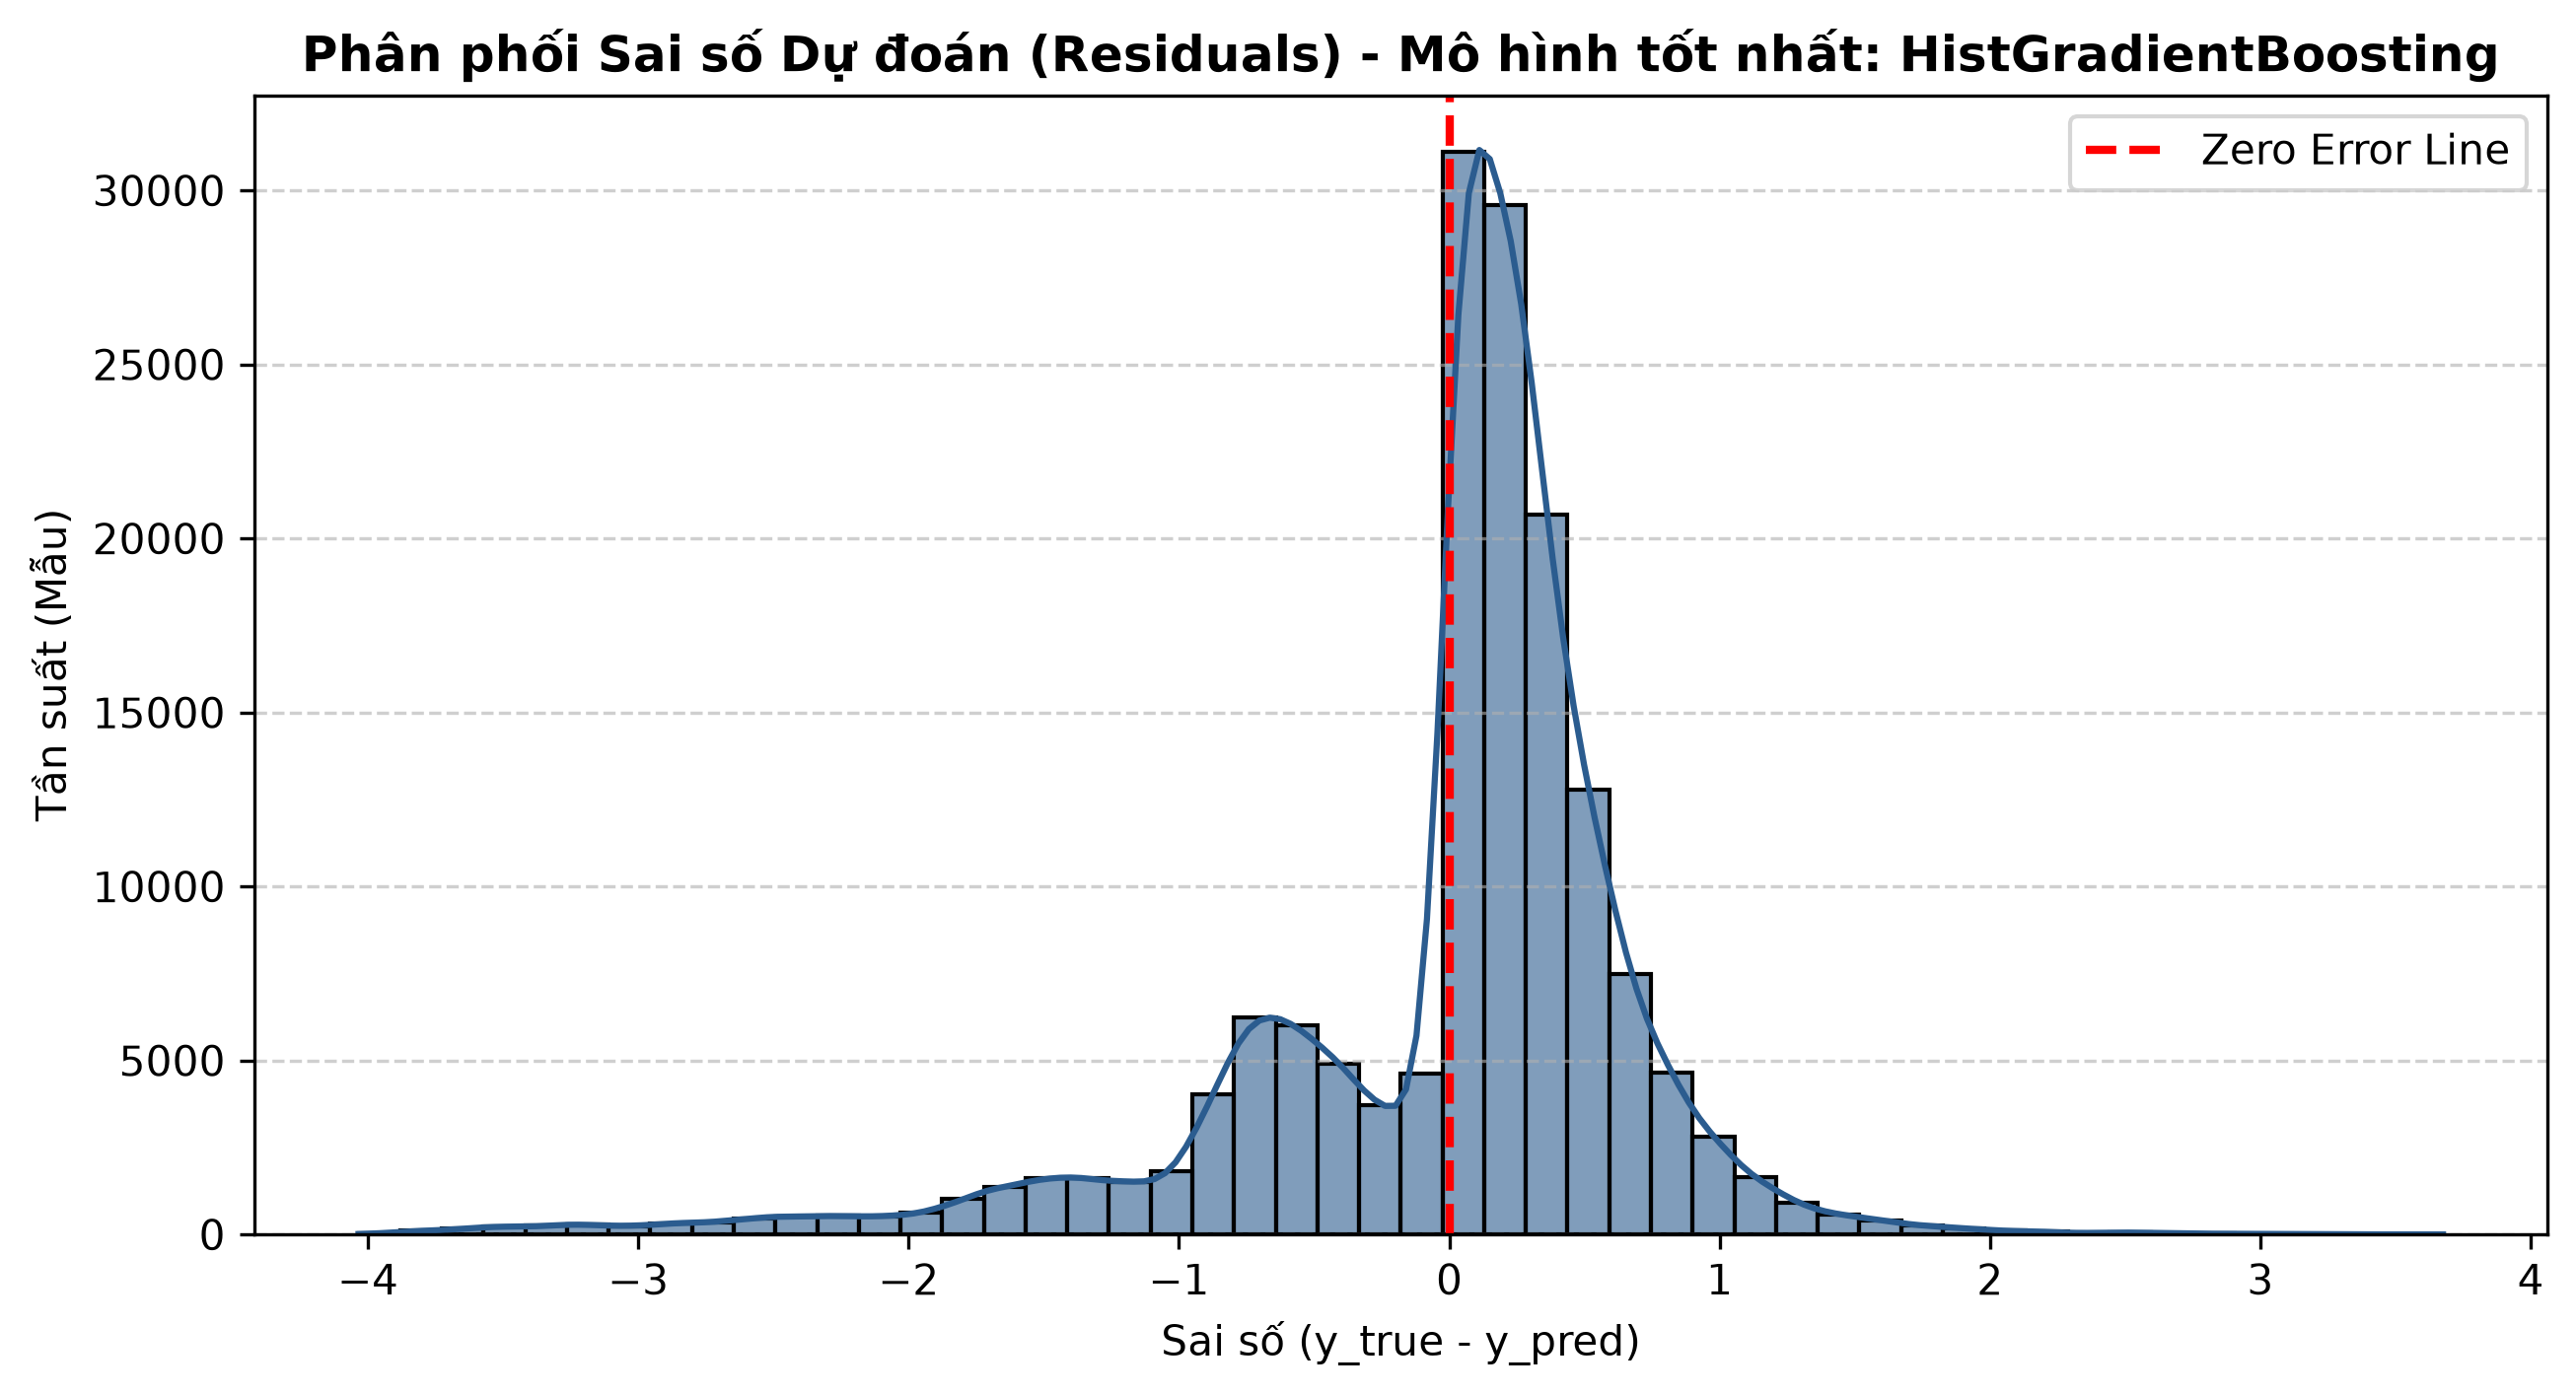

In [ ]:
# 1. Trực quan hóa so sánh 3 chỉ số MAE, RMSE, R²
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Biểu đồ MAE
sns.barplot(data=df_comparison, x='Model', y='MAE', ax=axes[0], palette='Blues_r', hue='Model', legend=False)
axes[0].set_title('Mean Absolute Error (MAE) - Càng thấp càng tốt', fontsize=12, fontweight='bold')
axes[0].set_ylabel('MAE Score')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 3), textcoords='offset points')

# Biểu đồ RMSE
sns.barplot(data=df_comparison, x='Model', y='RMSE', ax=axes[1], palette='Oranges_r', hue='Model', legend=False)
axes[1].set_title('Root Mean Squared Error (RMSE) - Càng thấp càng tốt', fontsize=12, fontweight='bold')
axes[1].set_ylabel('RMSE Score')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 3), textcoords='offset points')

# Biểu đồ R² Score
sns.barplot(data=df_comparison, x='Model', y='R² Score', ax=axes[2], palette='Greens_r', hue='Model', legend=False)
axes[2].set_title('R² Score (Variance Explained) - Càng cao càng tốt', fontsize=12, fontweight='bold')
axes[2].set_ylabel('R² Score')
axes[2].grid(axis='y', linestyle='--', alpha=0.7)
for p in axes[2].patches:
    axes[2].annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.savefig('Data/charts_img/baseline_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Phân phối sai số dự đoán của mô hình tốt nhất
best_model_name = df_comparison.iloc[0]['Model']
best_model = trained_models[best_model_name]
y_best_pred = best_model.predict(X_test)
residuals = y_test - y_best_pred

plt.figure(figsize=(10, 5))
sns.histplot(residuals, bins=50, kde=True, color='#2b5c8f', edgecolor='black', alpha=0.6)
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Đường sai số 0 (Zero Error Line)')
plt.title(f'Phân phối Sai số Dự đoán (Residuals) - Mô hình: {best_model_name}', fontsize=12, fontweight='bold')
plt.xlabel('Sai số dự đoán (y_true - y_pred)')
plt.ylabel('Tần suất (Số lượng mẫu)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.savefig('Data/charts_img/baseline_best_model_residuals.png', dpi=300, bbox_inches='tight')
plt.show()